# Eksperyment I: Pojemność architektur i zjawisko przeuczenia w modelach DDPM 1D

## 1. Cel badawczy i zakres eksperymentu
Głównym celem doświadczenia jest zbadanie wpływu pojemności jednowymiarowych modeli dyfuzyjnych (**DDPM 1D**) na zjawisko przeuczenia (*overfitting*) oraz ich zdolności generalizacyjne w zderzeniu ze stochastycznymi sygnałami.

Badanie opiera się na analizie zależności pomiędzy geometrią sieci przewidującej szum, liczbą jej wag (zależną od szerokości kanałów ukrytych $C$), a końcową jakością rekonstrukcji.

---

## 2. Hipotezy badawcze
W ramach eksperymentu weryfikacji podlegają następujące hipotezy:
1. **H1:** Modele o wysokiej pojemności, wyposażone w hierarchiczną strukturę splotową i połączenia omijające (*U-Net 1D*), szybciej minimalizują funkcję straty na zbiorze treningowym niż architektury płytkie lub w pełni połączone (*MLP*).
2. **H2:** Wraz ze wzrostem złożonści parametrycznej modeli o słabym skrzywieniu indukcyjnym (*inductive bias*) gwałtownie narasta zjawisko przeuczenia, objawiające się wzrostem błędu walidacyjnego przy jednoczesnym spadku błędu treningowego.
3. **H3:** Architektury oparte na splotach jednowymiarowych (*Conv1D*) wykazują znacznie wyższą stabilność numeryczną i zdolność do generalizacji lokalnych cech funkcji niestacjonarnych w porównaniu do klasycznych wielowarstwowych perceptronów (*MLP*).

## 3. Przestrzeń hiperparametrów 
Eksperyment został zaprojektowany jako wielokryterialne przeszukiwanie siatki parametrów. Proces uczenia realizowany jest drogą optymalizacji bezpośredniej wag przy ciągłej generacji próbek wejściowych w locie (*in situ*), co eliminuje problem skończoności zbioru danych i chroni modele przed zapamiętywaniem par sygnał-szum.

### Specyfikacja przestrzeni:
| Parametr / Komponent | Definicja / Zakres |
| :--- | :--- |
| **Samplery** | *Sine* (harmoniczne), *Chirp* (zmienna częstotliwość), *Hard* (niestacjonarne z nieciągłościami) |
| **Architektury sieci neuronowych** | Multi-Layer Perceptron (*MLP*), Convolutional 1D (*Conv1D*), Hierarchical *U-Net 1D* |
| **Pojemność ($C$)** | $C \in \{32, 64, 128, 256\}$ |
| **Współczynnik uczenia ($\eta$)** | $\eta \in \{10^{-3}, 5\cdot10^{-4}, 10^{-4}\}$ |
| **Liczba kroków dyfuzji ($T$)** | $T \in \{80, 100\}$ |
| **Rozmiar paczki (Batch Size)** | 64 próbki (rozdzielczość sygnału $N=128$ węzłów) |
| **Maksymalny limit epok** | 5000 |
| **Algorytm optymalizacji** | Adam |
| **Powtórzenia statystyczne** | 3 niezależne próby dla każdej konfiguracji (Seeds: 42, 43, 44) |

W celu pełnej izolacji losowości i zabezpieczenia przed wyciekiem danych (*data leakage*), stany generatorów stochastycznych dla podzbioru treningowego, walidacyjnego i testowego zostały odseparowane sztywnymi przesunięciami ziaren losowości (odpowiednio: $+0$, $+10\,000$, $+20\,000$).

---

## 4. Struktura potoku przetwarzania (Pipeline)
Notatnik został ustrukturyzowany w następujący sposób:

1. Inicjalizacja środowiska obliczeniowego.
   * Definicja silnika wykonawczego (`RobustCapacityRunner`).
2.  Grid Search z automatycznym zapisem wyników do plików `.pth`.
3. Równoległe potoki:
   * Modelowanie ważności hiperparametrów za pomocą Lasu Losowego.
   * (Makroskopowa analiza) Zestawienia globalne błędu MSE (wpływ pojemności, kroku uczenia i czasu dyfuzji).
   * (Mikroskopowa analiza) Śledzenie dynamiki uczenia, zjawiska przeuczenia i krzywych zbieżności.
   * Wybór konfiguracji do Eksperymentu II.

Wyniki końcowe są automatycznie zapisywane w postaci logów numerycznych, tabelarycznych plików CSV oraz  wykresów, stanowiących bezpośredni wkład graficzny do rozdziału czwartego pracy dyplomowej.

In [1]:
import numpy as np
import torch
import pandas as pd
import os
import sys
import matplotlib.pyplot as plt
from IPython.display import display
import seaborn as sns
from sklearn.ensemble import RandomForestRegressor
from typing import Dict, Any, Callable, Type

sys.path.append(os.path.abspath('..'))
from utils.samplers import sample_sin_batch, sample_chirp_batch, sample_hard_batch
import utils.visualisations as vis
from models.ddpm1d import DDPM1D, get_beta_schedule
from models.mlp import DenoiseNet1D_MLP
from models.conv1d import DenoiseNet1D_Conv
from models.unet import DenoiseNet1D_UNet

import warnings
warnings.filterwarnings('ignore') 
%matplotlib inline

In [2]:
import os
import torch
import numpy as np
from typing import Dict, Any, Callable, Type
import warnings

warnings.filterwarnings("ignore", category=UserWarning)

class RobustCapacityRunner:
    def __init__(self, num_runs: int = 3, device: str = None):
        self.num_runs = num_runs
        self.device = torch.device(device if device else ('cuda' if torch.cuda.is_available() else 'cpu'))
        
        self.checkpoints_dir = os.path.join('experiments/checkpoints1')
        self.plots_dir = os.path.join('../images/experiment1')
        
        for path in [
            self.checkpoints_dir, 
            self.plots_dir, 
            os.path.join(self.plots_dir, 'learning_curves'), 
            os.path.join(self.plots_dir, 'summary_heatmaps')
        ]:
            os.makedirs(path, exist_ok=True)

    def _init_model(self, model_class: Type[torch.nn.Module], capacity: int) -> torch.nn.Module:
        try:
            model = model_class(data_dim=128, base_channels=capacity).to(self.device)
        except TypeError:
            model = model_class(data_dim=128, hidden_dim=capacity).to(self.device)
                
        return model

    def run_robust_experiment(
        self, 
        func_name: str, 
        sampler_func: Callable, 
        architectures: Dict[str, Type[torch.nn.Module]], 
        capacities: Dict[str, int], 
        epochs: int, 
        n_steps: int, 
        learning_rate: float, 
        batch_size: int = 64
    ) -> Dict[str, Any]:
        
        header = f" EXPERIMENT: {func_name.upper()} | LR: {learning_rate} | T: {n_steps} "
        print(f"\n{'='*len(header)}\n{header}\n{'='*len(header)}")
        
        results = {}
        betas = get_beta_schedule('linear', 1e-4, 0.02, n_steps)

        for arch_name, model_class in architectures.items():
            results[arch_name] = {}
            
            for cap_name, capacity_val in capacities.items():
                print(f"\n[CONFIG] Arch: {arch_name:7} | Capacity: {cap_name:7}")
                
                prefix = f"{func_name}_{arch_name}_{cap_name}_LR{learning_rate}_T{n_steps}"
                res_path = os.path.join(self.checkpoints_dir, f"{prefix}_stats.pth")
                plot_path = os.path.join(self.plots_dir, f"learning_curves/plot_{prefix}.png")
                
                if os.path.exists(res_path):
                    print(f"[CACHE] Loading existing results for {prefix}")
                    stat_results = torch.load(res_path, weights_only=False)
                    results[arch_name][cap_name] = stat_results
                    
                    if not os.path.exists(plot_path) and 'train_mat' in stat_results:
                        self._generate_report_plot(
                            stat_results['train_mat'], 
                            stat_results['val_mat'], 
                            arch_name, cap_name, func_name, learning_rate, n_steps
                        )
                    continue

                metrics_accumulator = {'train_loss': [], 'val_loss': [], 'test_loss': []}
                num_params_recorded = 0
                last_model_state = None 

                for run_id in range(self.num_runs):
                    seed = 42 + run_id
                    print(f"  -> Trial {run_id + 1}/{self.num_runs} (Seed: {seed})", end='\r')
                    
                    trial_results = self._run_single_trial(
                        run_id, seed, func_name, sampler_func, model_class, 
                        capacity_val, epochs, n_steps, betas, learning_rate, batch_size
                    )
                    
                    metrics_accumulator['train_loss'].append(trial_results['train_history'])
                    metrics_accumulator['val_loss'].append(trial_results['val_history'])
                    metrics_accumulator['test_loss'].append(trial_results['test_score'])
                    num_params_recorded = trial_results['num_params']
                    last_model_state = trial_results['state_dict']
                
                print() 
                
                train_mat = np.array(metrics_accumulator['train_loss'])
                val_mat = np.array(metrics_accumulator['val_loss'])
                test_scores = np.array(metrics_accumulator['test_loss'])
                
                stat_results = {
                    'num_params': num_params_recorded,
                    'train_mu': np.mean(train_mat[:, -1]),
                    'train_std': np.std(train_mat[:, -1]),
                    'val_mu': np.mean(val_mat[:, -1]),
                    'val_std': np.std(val_mat[:, -1]),
                    'test_mu': np.mean(test_scores),
                    'test_std': np.std(test_scores),
                    'train_mat': train_mat,
                    'val_mat': val_mat
                }
                
                results[arch_name][cap_name] = stat_results
                torch.save(stat_results, res_path)
                
                weights_path = os.path.join(self.checkpoints_dir, f"{prefix}_weights.pth")
                torch.save(last_model_state, weights_path)
                
                print(f"  [RESULT] Test Loss: {stat_results['test_mu']:.5f} ± {stat_results['test_std']:.5f}")
                self._generate_report_plot(train_mat, val_mat, arch_name, cap_name, func_name, learning_rate, n_steps)
                
        heatmap_path = os.path.join(self.plots_dir, f"summary_heatmaps/heatmap_{func_name}_LR{learning_rate}_T{n_steps}.png")
        vis.plot_summary_heatmap(results, func_name, learning_rate, n_steps, heatmap_path)
        
        return results

    def _run_single_trial(self, run_id, seed, func_name, sampler, model_class, 
                          capacity, epochs, n_steps, betas, lr, bs):
    
        np.random.seed(seed + 10000)
        torch.manual_seed(seed + 10000)
        val_data = sampler(256).to(self.device) 
        
        np.random.seed(seed + 20000)
        torch.manual_seed(seed + 20000)
        test_data = sampler(256).to(self.device)
    
        model = self._init_model(model_class, capacity)
        ddpm = DDPM1D(model, betas, n_steps, self.device)
        optimizer = torch.optim.Adam(ddpm.model.parameters(), lr=lr)
        
        num_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
        
        use_amp = self.device.type == 'cuda'
        scaler = torch.cuda.amp.GradScaler(enabled=use_amp)
        
        train_h, val_h = [], []
        
        np.random.seed(seed + 0)
        torch.manual_seed(seed + 0)
        
        current_val_loss = float('inf')
        val_freq = 10  
    
        for epoch in range(epochs):
            ddpm.model.train()
            optimizer.zero_grad()
            
            train_data = sampler(bs).to(self.device)
            
            with torch.autocast(device_type=self.device.type, dtype=torch.float16, enabled=use_amp):
                loss = ddpm.compute_loss(train_data) 
            
            scaler.scale(loss).backward()
            scaler.step(optimizer)
            scaler.update()
            
            train_h.append(loss.item())
            
            if epoch % val_freq == 0 or epoch == epochs - 1:
                ddpm.model.eval()
                with torch.no_grad():
                    with torch.autocast(device_type=self.device.type, dtype=torch.float16, enabled=use_amp):
                        v_loss = ddpm.compute_loss(val_data)
                    current_val_loss = v_loss.item()
                    
            val_h.append(current_val_loss)

        ddpm.model.eval()
        with torch.no_grad():
            with torch.autocast(device_type=self.device.type, dtype=torch.float16, enabled=use_amp):
                test_score = ddpm.compute_loss(test_data).item()
        
        return {
            'train_history': train_h, 
            'val_history': val_h, 
            'test_score': test_score,
            'num_params': num_params,
            'state_dict': model.state_dict() 
        }

    def _generate_report_plot(self, train_mat, val_mat, arch, cap, func, lr, t):
        prefix = f"{func}_{arch}_{cap}_LR{lr}_T{t}"
        save_path = os.path.join(self.plots_dir, f"learning_curves/plot_{prefix}.png")
        vis.plot_learning_curves_with_ci(train_mat, val_mat, arch, cap, func, save_path)

In [3]:
if __name__ == "__main__":
    runner = RobustCapacityRunner(num_runs=3, device='cuda')
    
    samplers = {
        "Sine": sample_sin_batch,       
        "Chirp": sample_chirp_batch,    
        "Hard": sample_hard_batch       
    }    
    architectures = {
        "MLP": DenoiseNet1D_MLP,
        "Conv1D": DenoiseNet1D_Conv,
        "UNet": DenoiseNet1D_UNet
    }
    
    capacities = {
        'C32': 32,   
        'C64': 64,
        'C128': 128,
        'C256': 256
  #      'C512': 512    
    }
    
    learning_rates = [1e-3, 5e-4, 1e-4]
    T_steps_options = [80, 100]
    EPOCHS =  5000
    
    best_results = {}

    # GRID SEARCH
    for sample_name in samplers: 
        for lr in learning_rates:
            for t_steps in T_steps_options:                          
                results = runner.run_robust_experiment(
                    func_name=sample_name,
                    sampler_func=samplers[sample_name],
                    architectures=architectures,
                    capacities=capacities,
                    epochs=EPOCHS,
                    n_steps=t_steps,
                    learning_rate=lr
                )
                
                config_key = f"LR_{lr}_T_{t_steps}"
                if config_key not in best_results:
                    best_results[config_key] = {}
                best_results[config_key][sample_name] = results

    # GENEROWANIE WYKRESÓW PORÓWNAWCZYCH LR 
    print("\n[INFO] Generowanie zbiorczych wykresów porównawczych LR...")
    for sample_name in samplers.keys():
        for t_steps in T_steps_options:
            for arch in architectures.keys():
                for cap in capacities.keys():
                    lr_data = {}
                    for lr in learning_rates:
                        prefix = f"{sample_name}_{arch}_{cap}_LR{lr}_T{t_steps}"
                        res_path = os.path.join('checkpoints1', f"{prefix}_stats.pth")
                        
                        if os.path.exists(res_path):
                            data = torch.load(res_path, weights_only=False)
                            lr_data[lr] = data['train_mat'] 
                    
                    if lr_data:
                        save_path = f"../images/experiment1/lr_comparison/lr_compare_{sample_name}_{arch}_{cap}_T{t_steps}.png"
                        vis.plot_lr_comparison(lr_data, arch, cap, sample_name, save_path)


 EXPERIMENT: SINE | LR: 0.001 | T: 80 

[CONFIG] Arch: MLP     | Capacity: C32    
[CACHE] Loading existing results for Sine_MLP_C32_LR0.001_T80

[CONFIG] Arch: MLP     | Capacity: C64    
[CACHE] Loading existing results for Sine_MLP_C64_LR0.001_T80

[CONFIG] Arch: MLP     | Capacity: C128   
[CACHE] Loading existing results for Sine_MLP_C128_LR0.001_T80

[CONFIG] Arch: MLP     | Capacity: C256   
[CACHE] Loading existing results for Sine_MLP_C256_LR0.001_T80

[CONFIG] Arch: Conv1D  | Capacity: C32    
[CACHE] Loading existing results for Sine_Conv1D_C32_LR0.001_T80

[CONFIG] Arch: Conv1D  | Capacity: C64    
[CACHE] Loading existing results for Sine_Conv1D_C64_LR0.001_T80

[CONFIG] Arch: Conv1D  | Capacity: C128   
[CACHE] Loading existing results for Sine_Conv1D_C128_LR0.001_T80

[CONFIG] Arch: Conv1D  | Capacity: C256   
[CACHE] Loading existing results for Sine_Conv1D_C256_LR0.001_T80

[CONFIG] Arch: UNet    | Capacity: C32    
[CACHE] Loading existing results for Sine_UNet_C32_L

In [4]:
df = vis.load_full_experiment_data('experiments/checkpoints1')

In [5]:
display(df)

,Funkcja,Architektura,Pojemność,LR,T,Train_MSE,Val_MSE,Test_MSE,Test_STD,Liczba parametrów
0,Chirp,Conv1D,128,0.0001,100,0.072682,0.072973,0.072134,0.004269,698817
1,Chirp,Conv1D,128,0.0001,80,0.066294,0.071048,0.070781,0.002863,698817
2,Chirp,Conv1D,128,0.0005,100,0.055252,0.056587,0.055417,0.004451,698817
3,Chirp,Conv1D,128,0.0005,80,0.054086,0.054281,0.053525,0.003147,698817
4,Chirp,Conv1D,128,0.0010,100,0.053271,0.056279,0.054929,0.004825,698817
...,...,...,...,...,...,...,...,...,...,...
211,Sine,UNet,64,0.0001,80,0.047493,0.049590,0.047106,0.002490,1071169
212,Sine,UNet,64,0.0005,100,0.041178,0.041882,0.040292,0.000643,1071169
213,Sine,UNet,64,0.0005,80,0.039670,0.043225,0.040490,0.000621,1071169
214,Sine,UNet,64,0.0010,100,0.040457,0.042697,0.040661,0.000871,1071169


# I. Wizualizacje

## 1. Obraz makroskopowy i ważność hiperparametrów

Wykres słupkowy Random Forest (Ważność hiperparametrów)

In [6]:
if not df.empty:
    df_ml = df.copy()
    df_ml['Architektura_Kod'] = df_ml['Architektura'].astype('category').cat.codes
    
    X = df_ml[['Architektura_Kod', 'Pojemność', 'LR', 'T']]
    y = df_ml['Test_MSE']
    
    rf = RandomForestRegressor(n_estimators=100, random_state=42)
    rf.fit(X, y)
    
    importances = rf.feature_importances_
    features = ['Architektura', 'Capacity', 'Learning Rate', 'Kroki (T)']
    
    importance_df = pd.DataFrame({'Parametr': features, 'Wpływ na MSE': importances})
    importance_df = importance_df.sort_values(by='Wpływ na MSE', ascending=False)
    
    display(importance_df.style.format({'Wpływ na MSE': '{:.1%}'}))

,Parametr,Wpływ na MSE
0,Architektura,81.7%
1,Capacity,15.5%
2,Learning Rate,2.1%
3,Kroki (T),0.7%


Zbiorcze wykresy pudełkowe (Boxplots dla Architektury, Pojemności, LR, T)

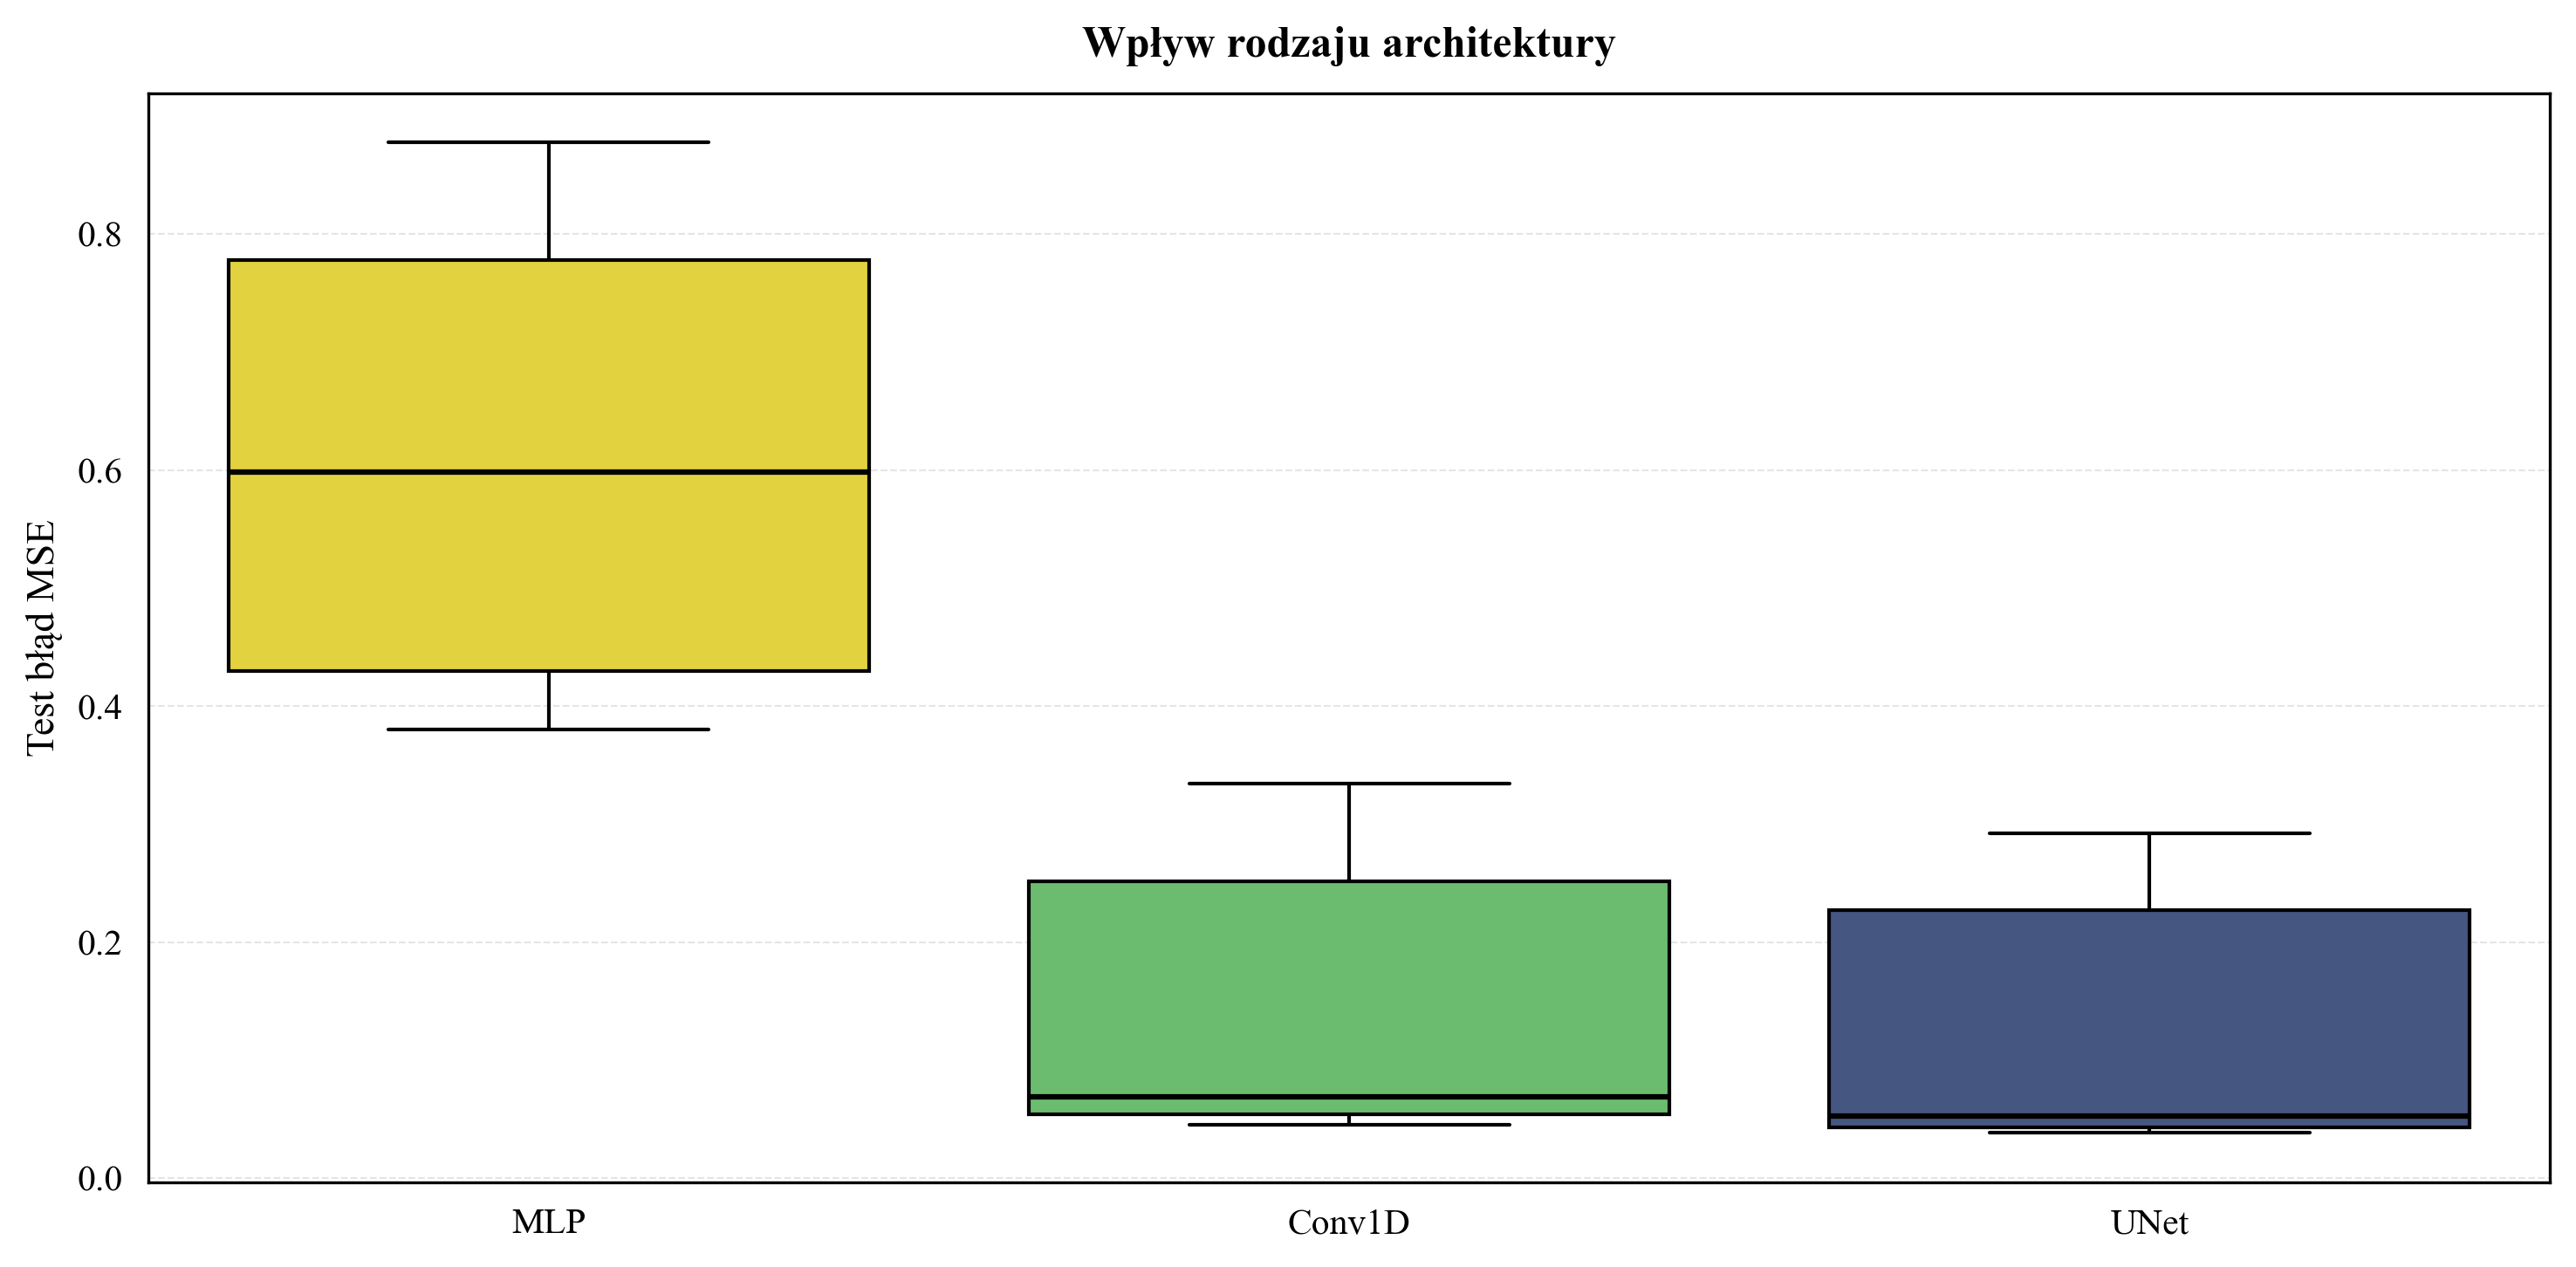

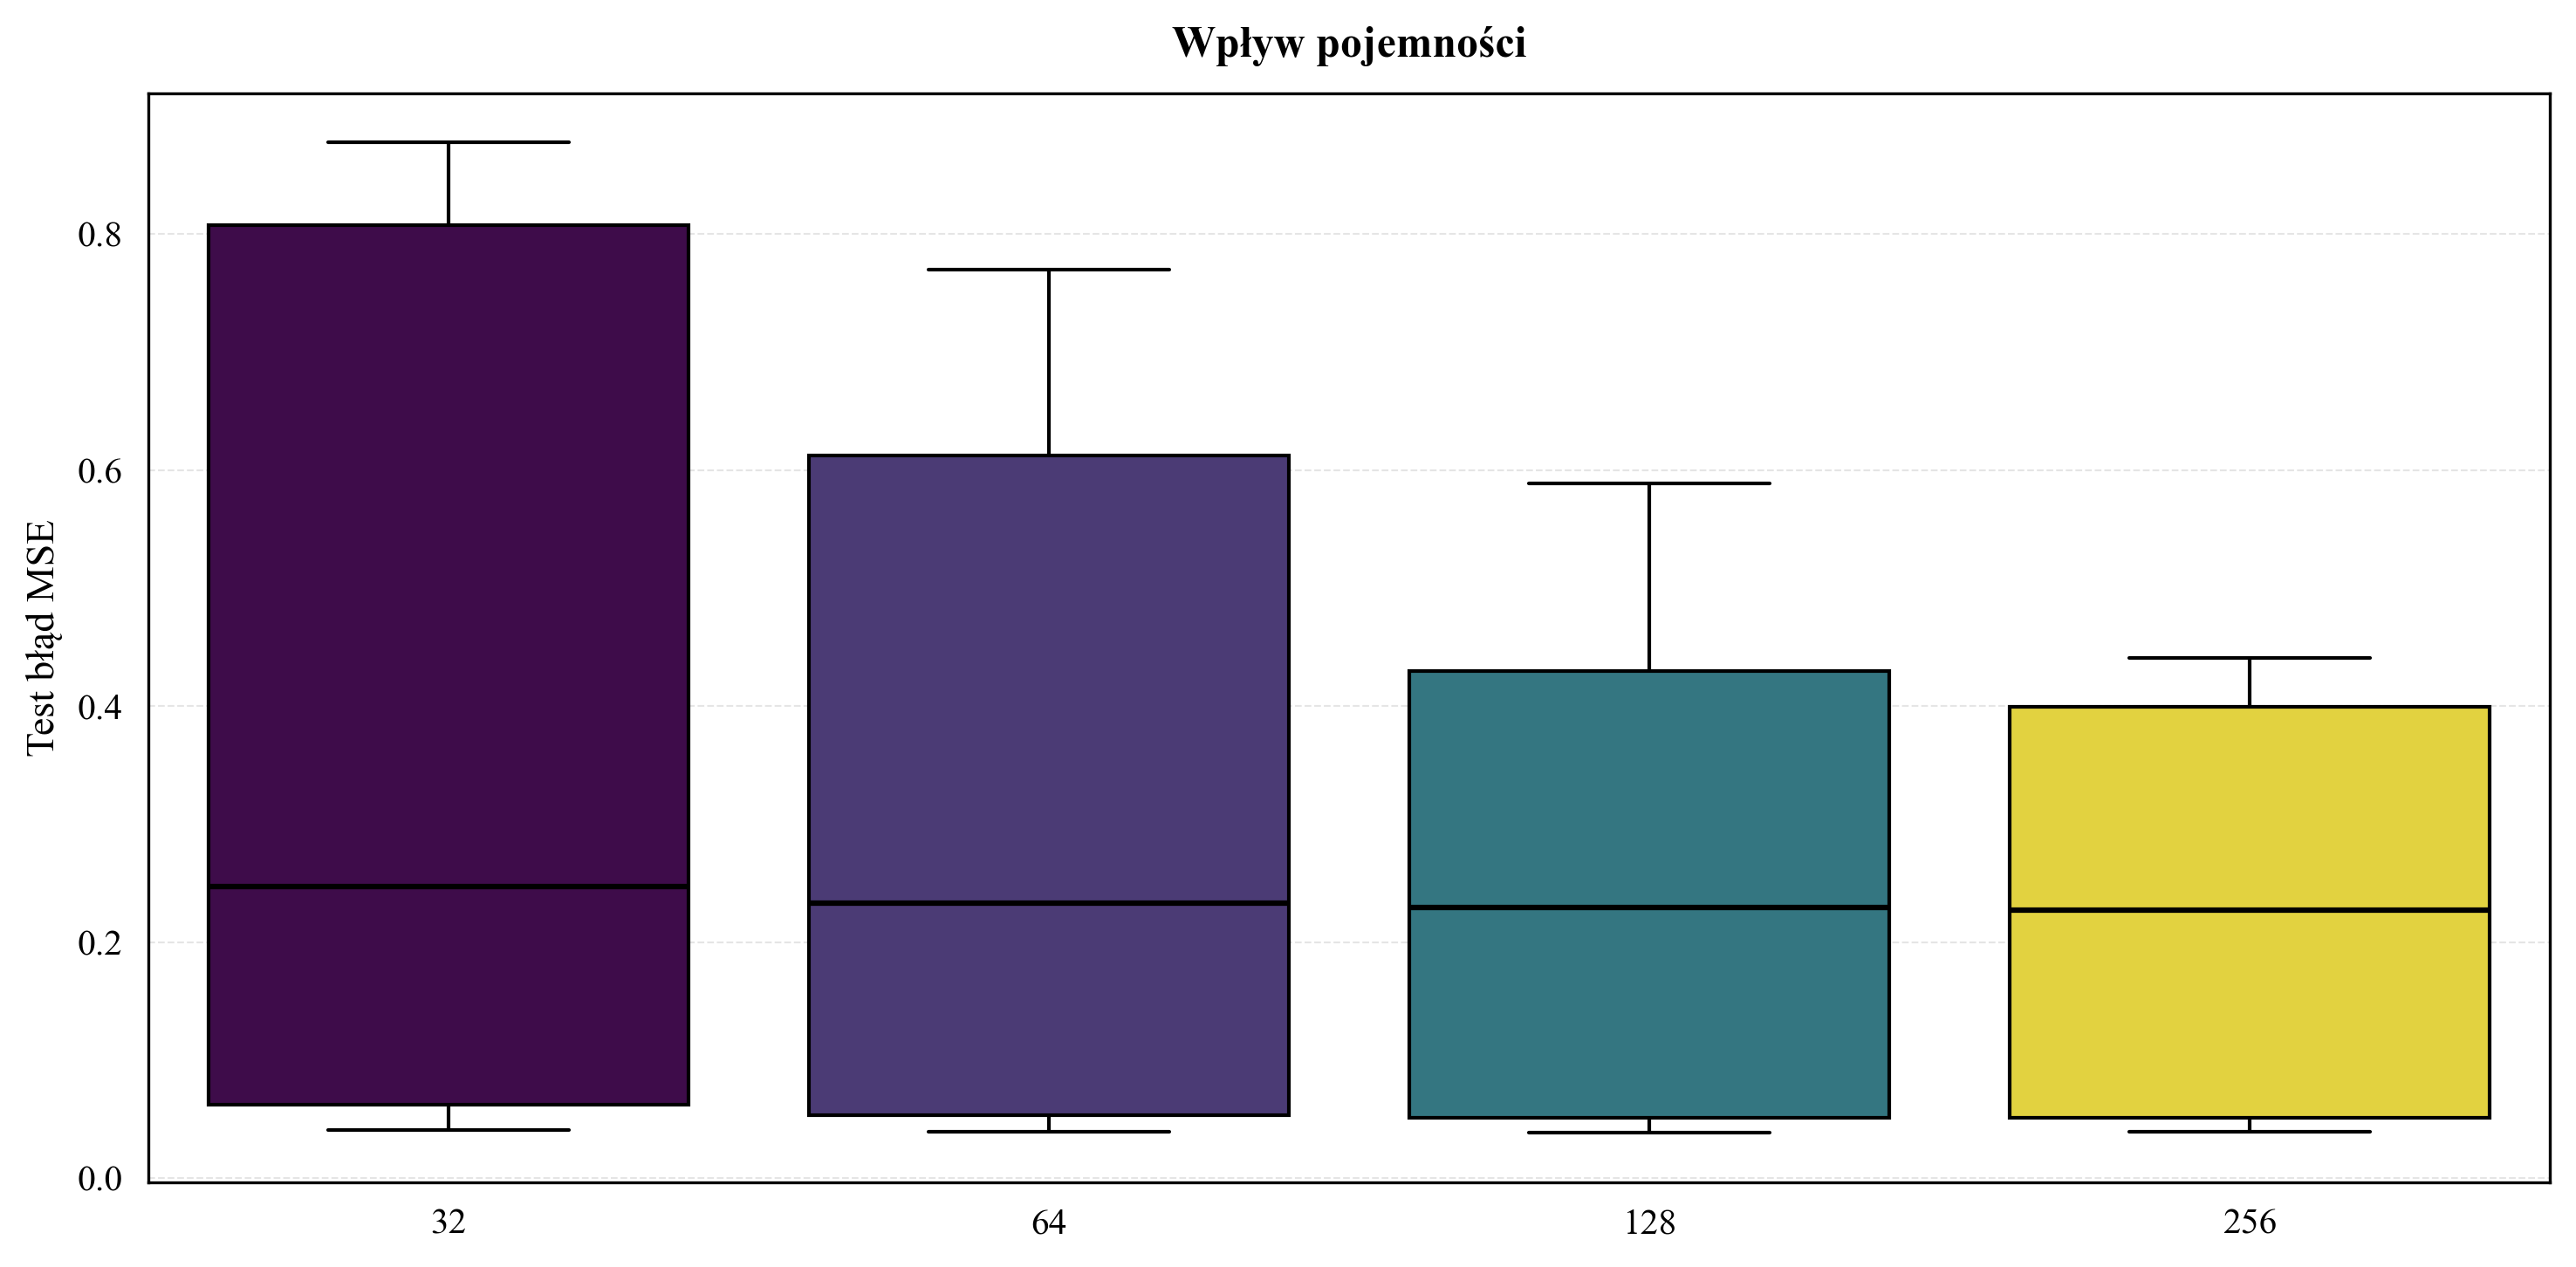

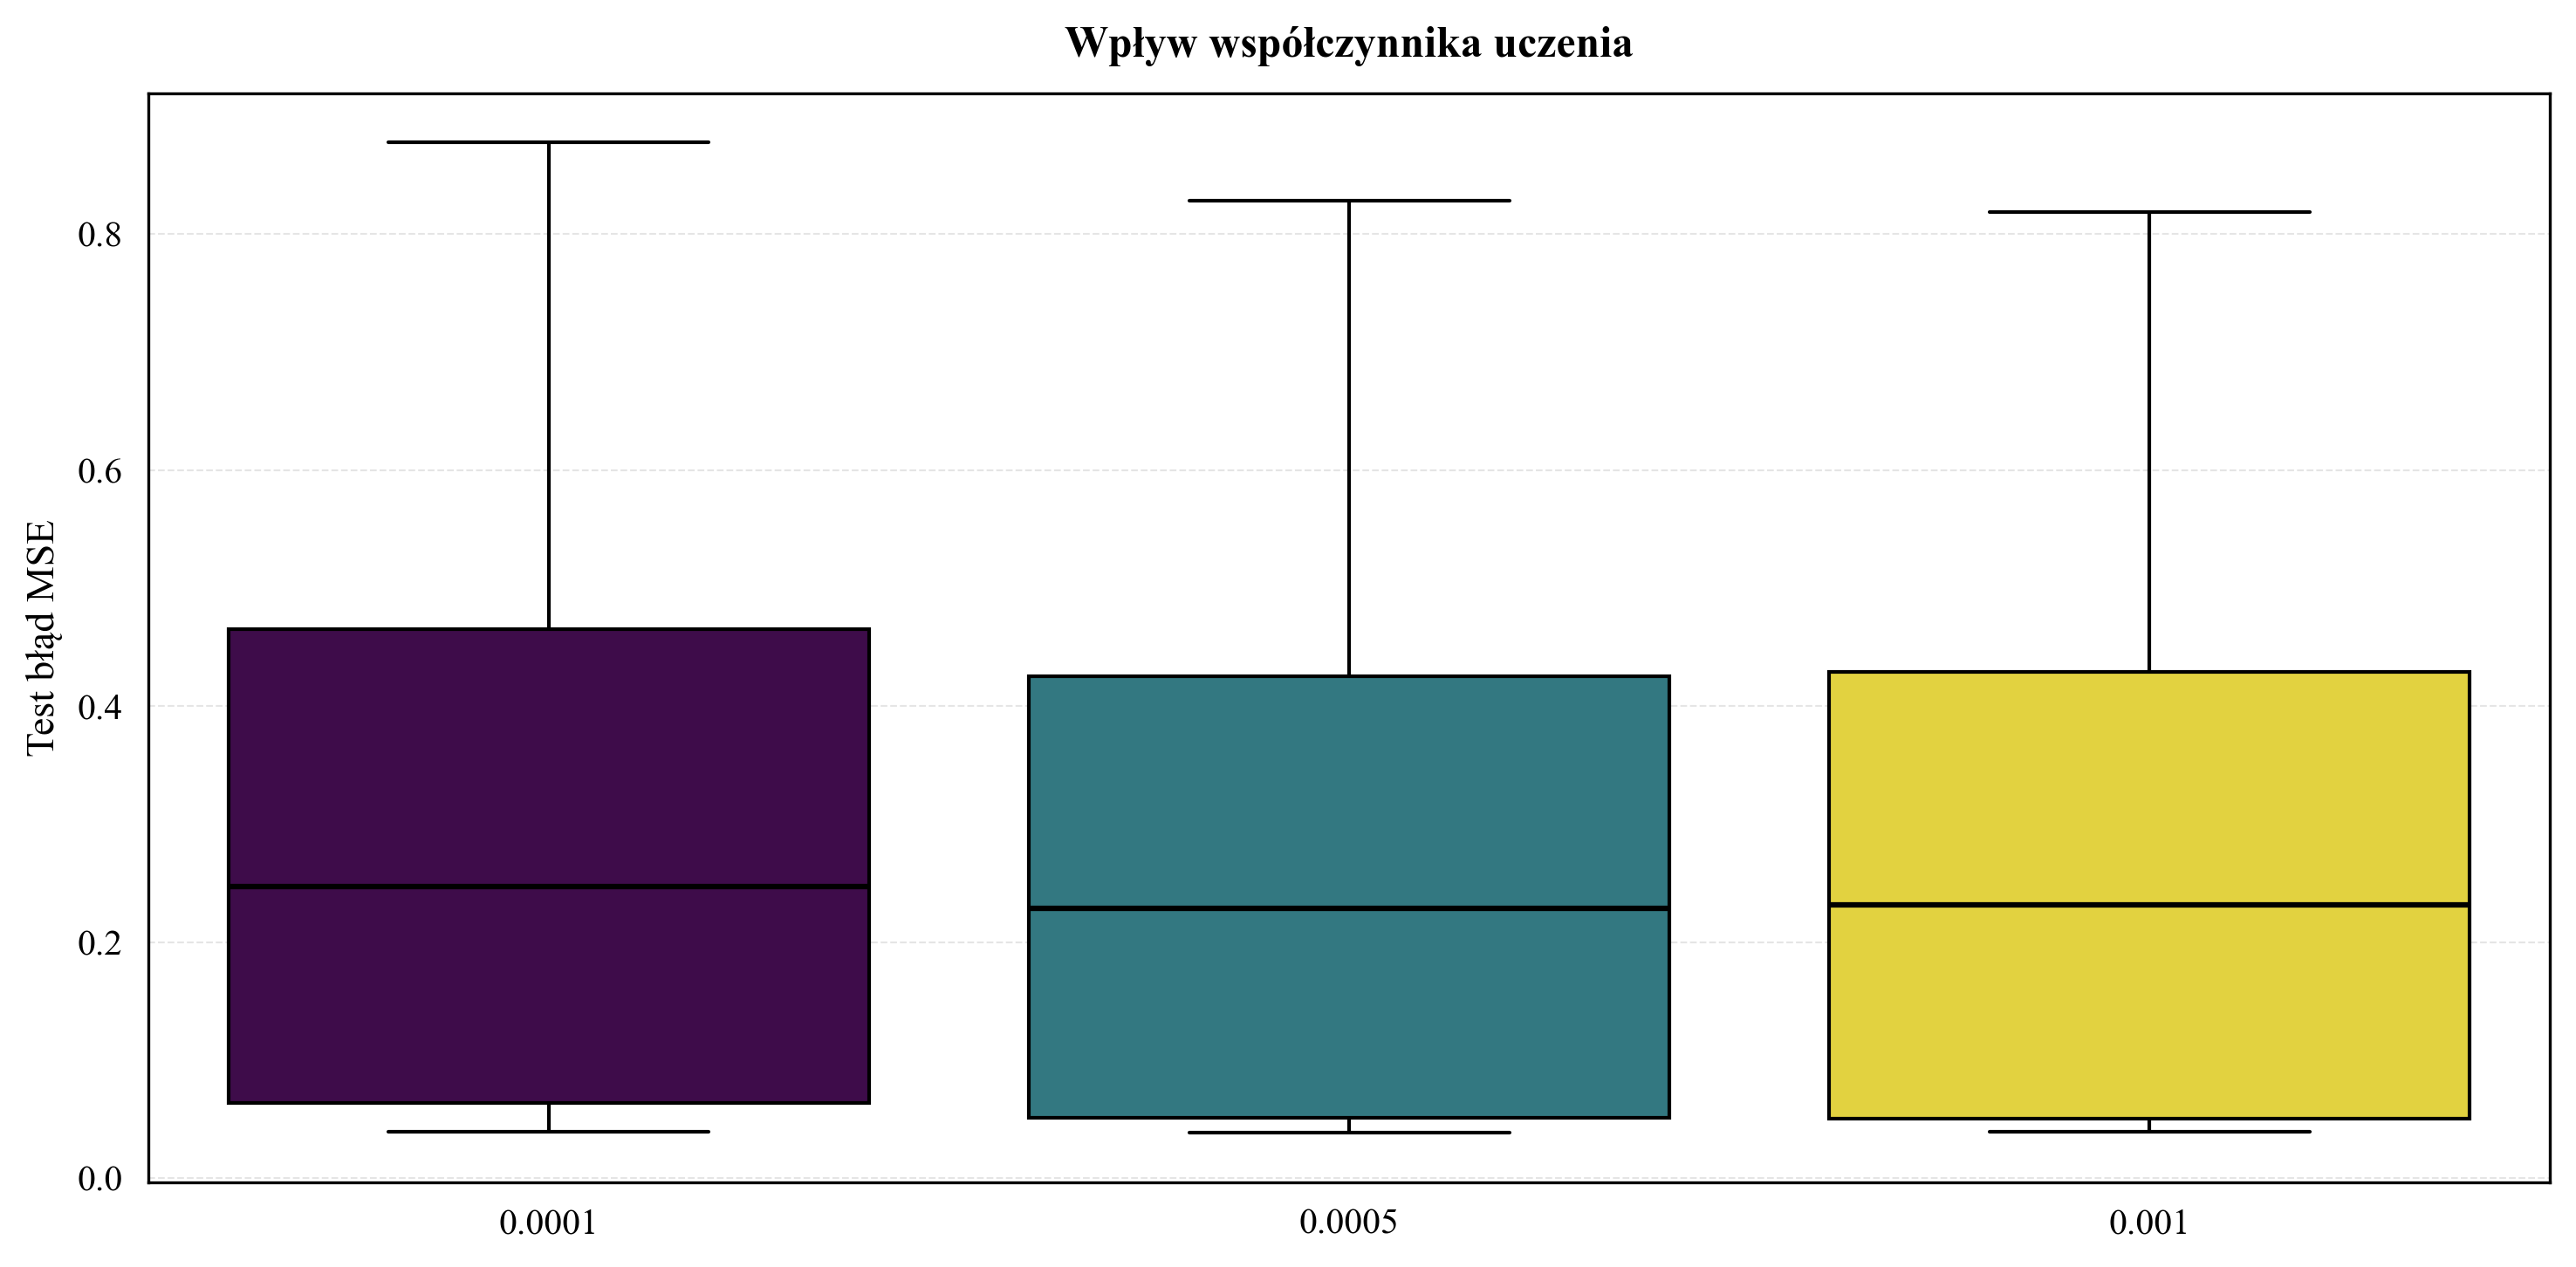

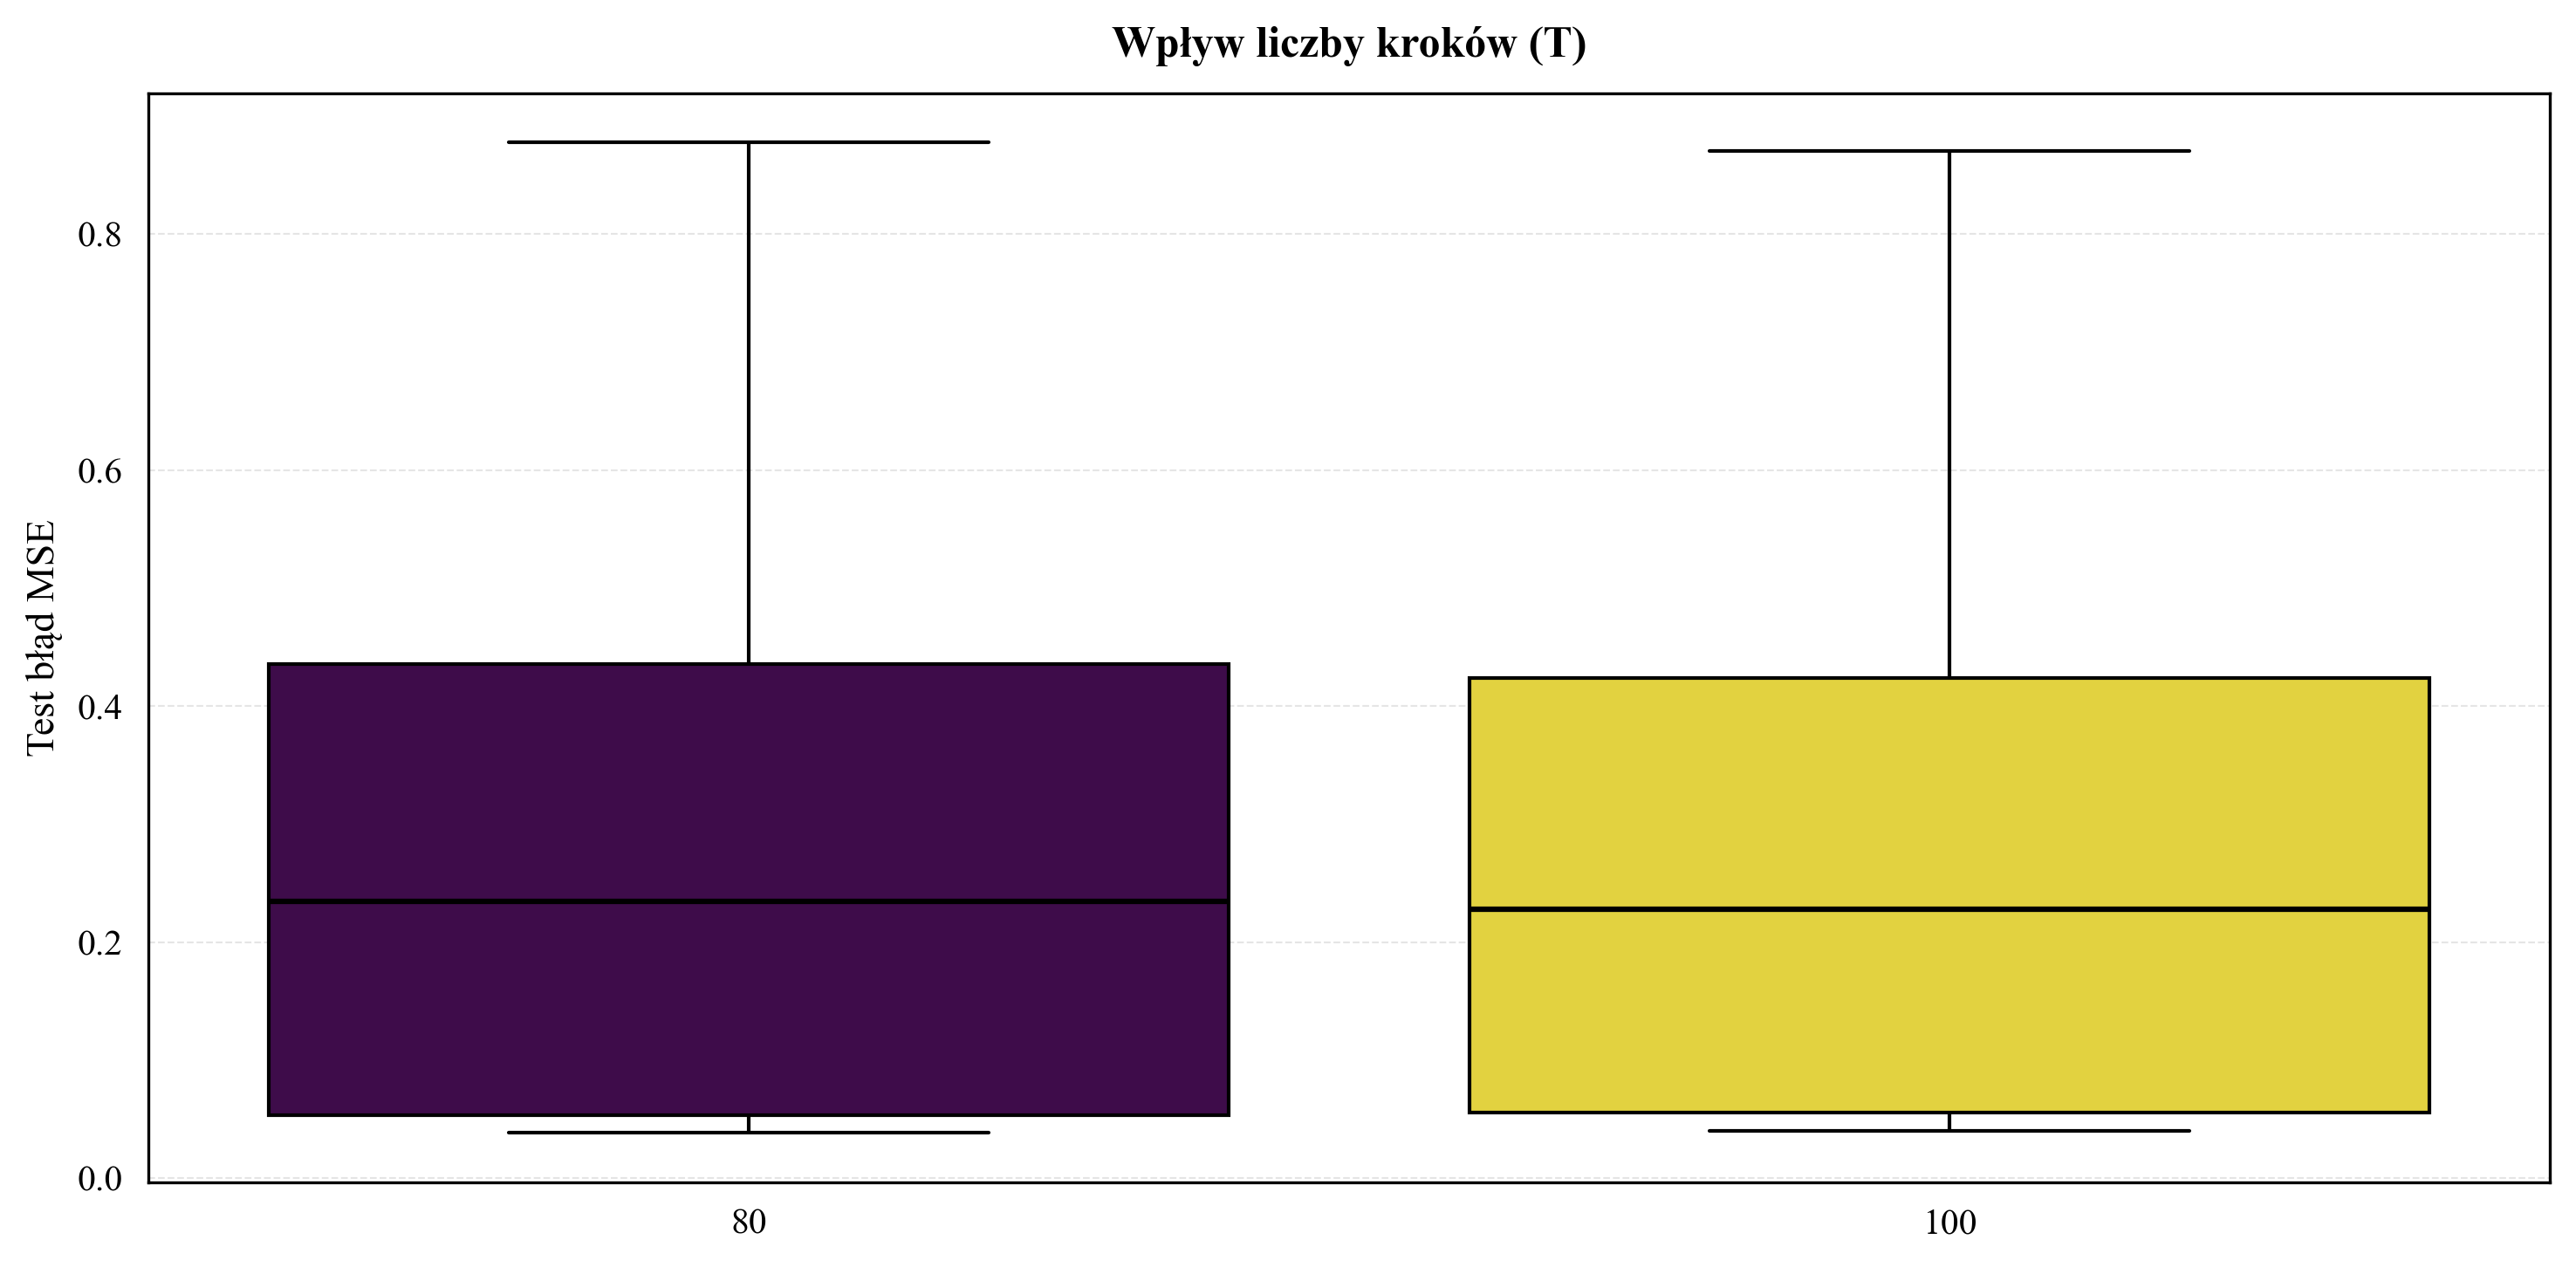

In [7]:
vis.plot_experiment_ablation_boxplots(df, use_log_scale=False)


Zdolność architektur do rekonstrukcji funkcji


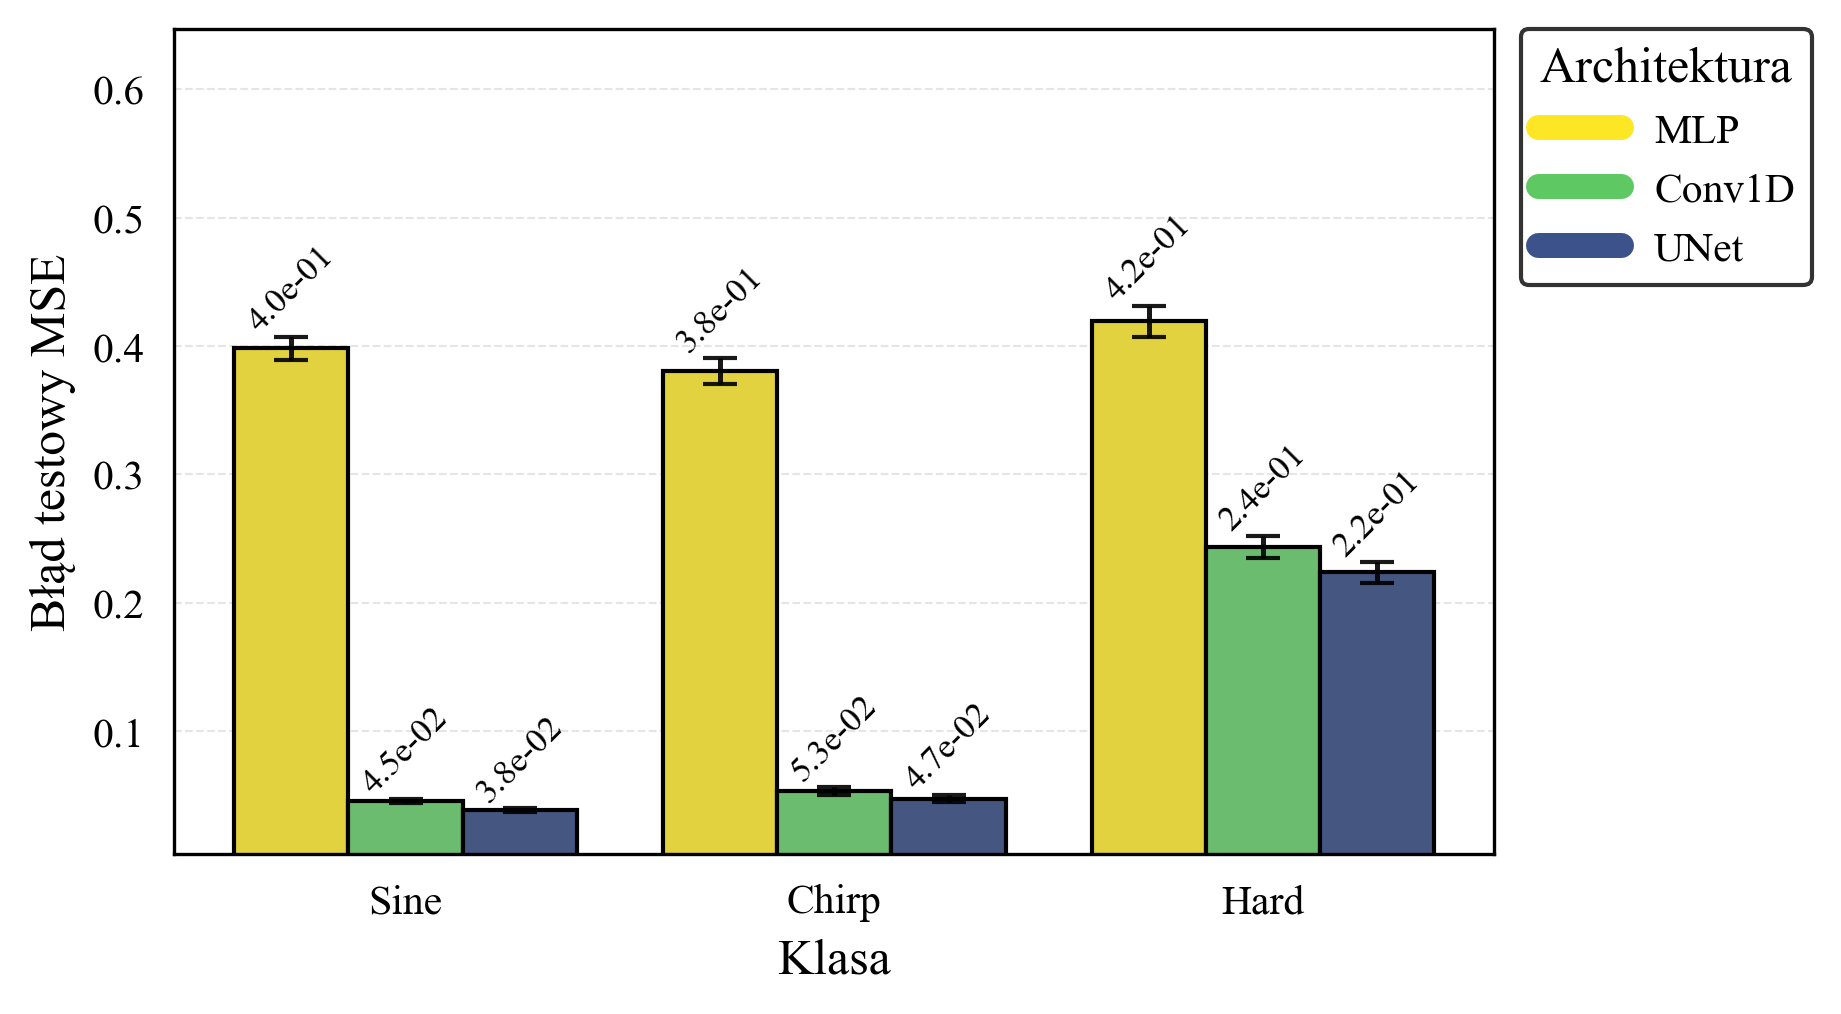

In [8]:
print("Zdolność architektur do rekonstrukcji funkcji")
vis.visualize_styled_stats_final(folder='experiments/checkpoints1')

In [9]:
print("Zależność błędu testowego od parametrów")
vis.create_split_heatmap(folder='experiments/checkpoints1')

Zależność błędu testowego od parametrów


Generowanie makroskopowych zestawień statystycznych błędu MSE względem parametrów LR


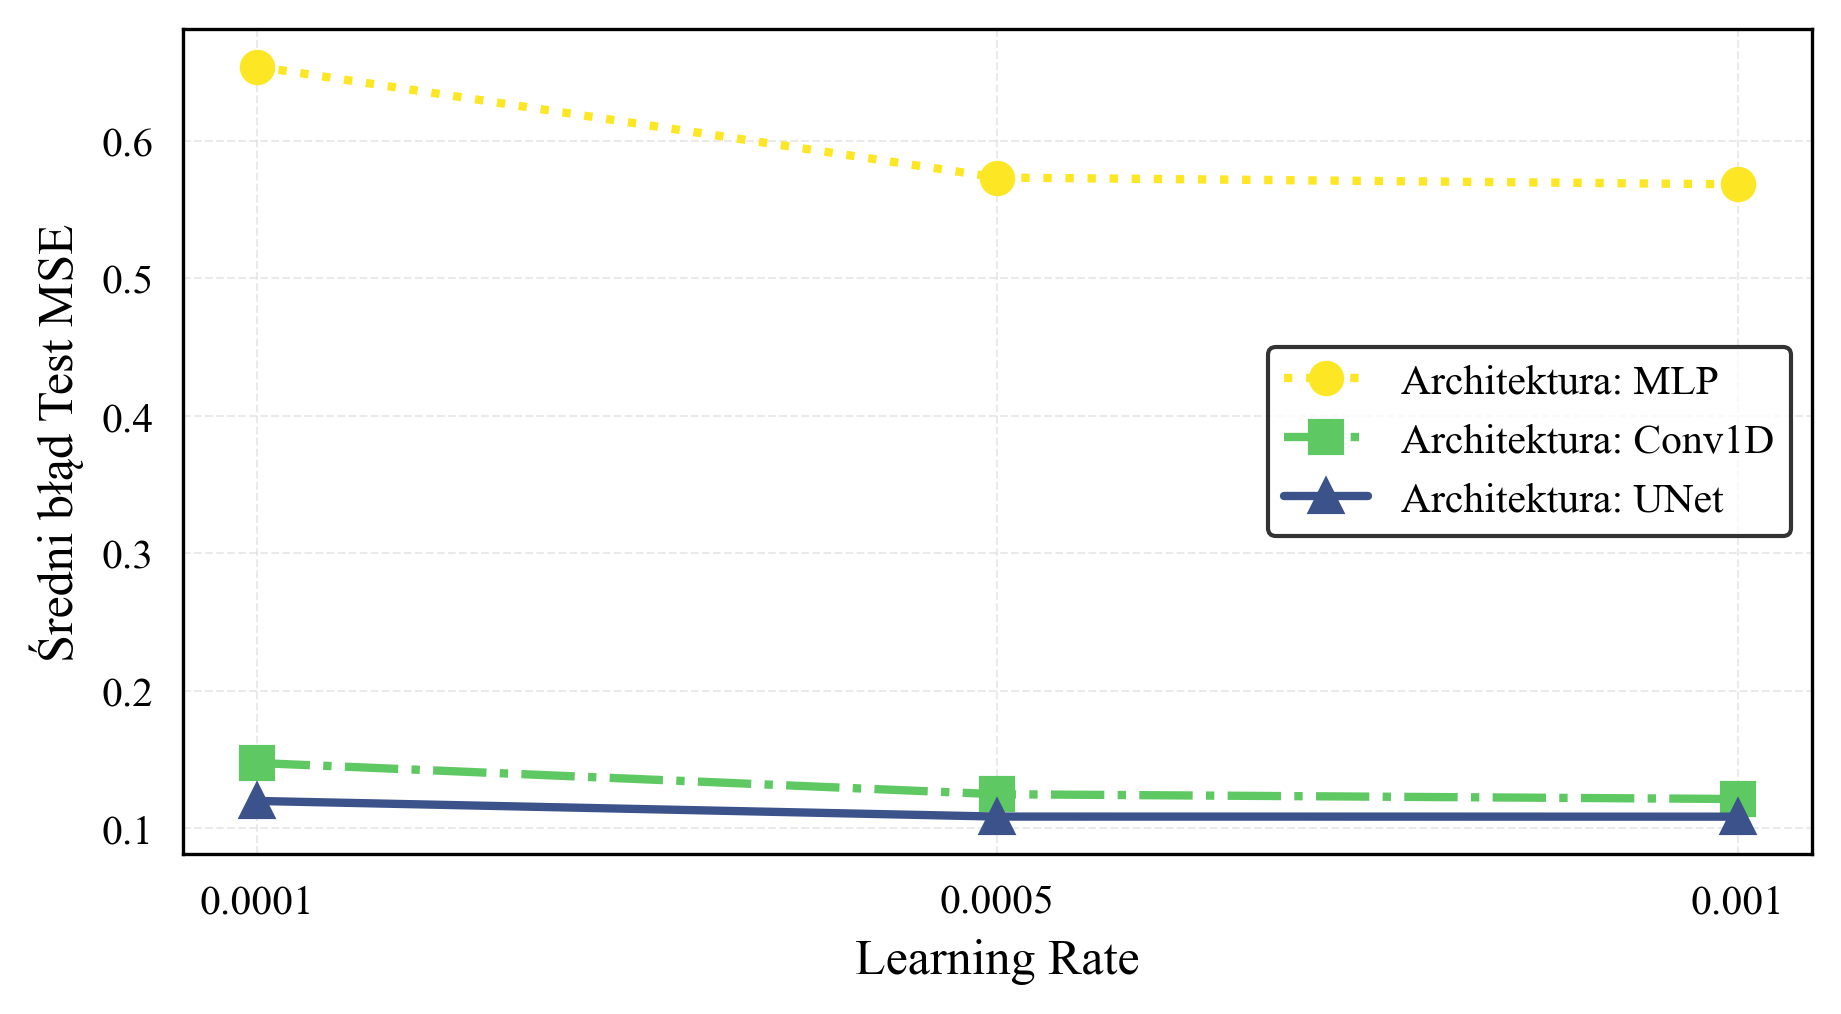

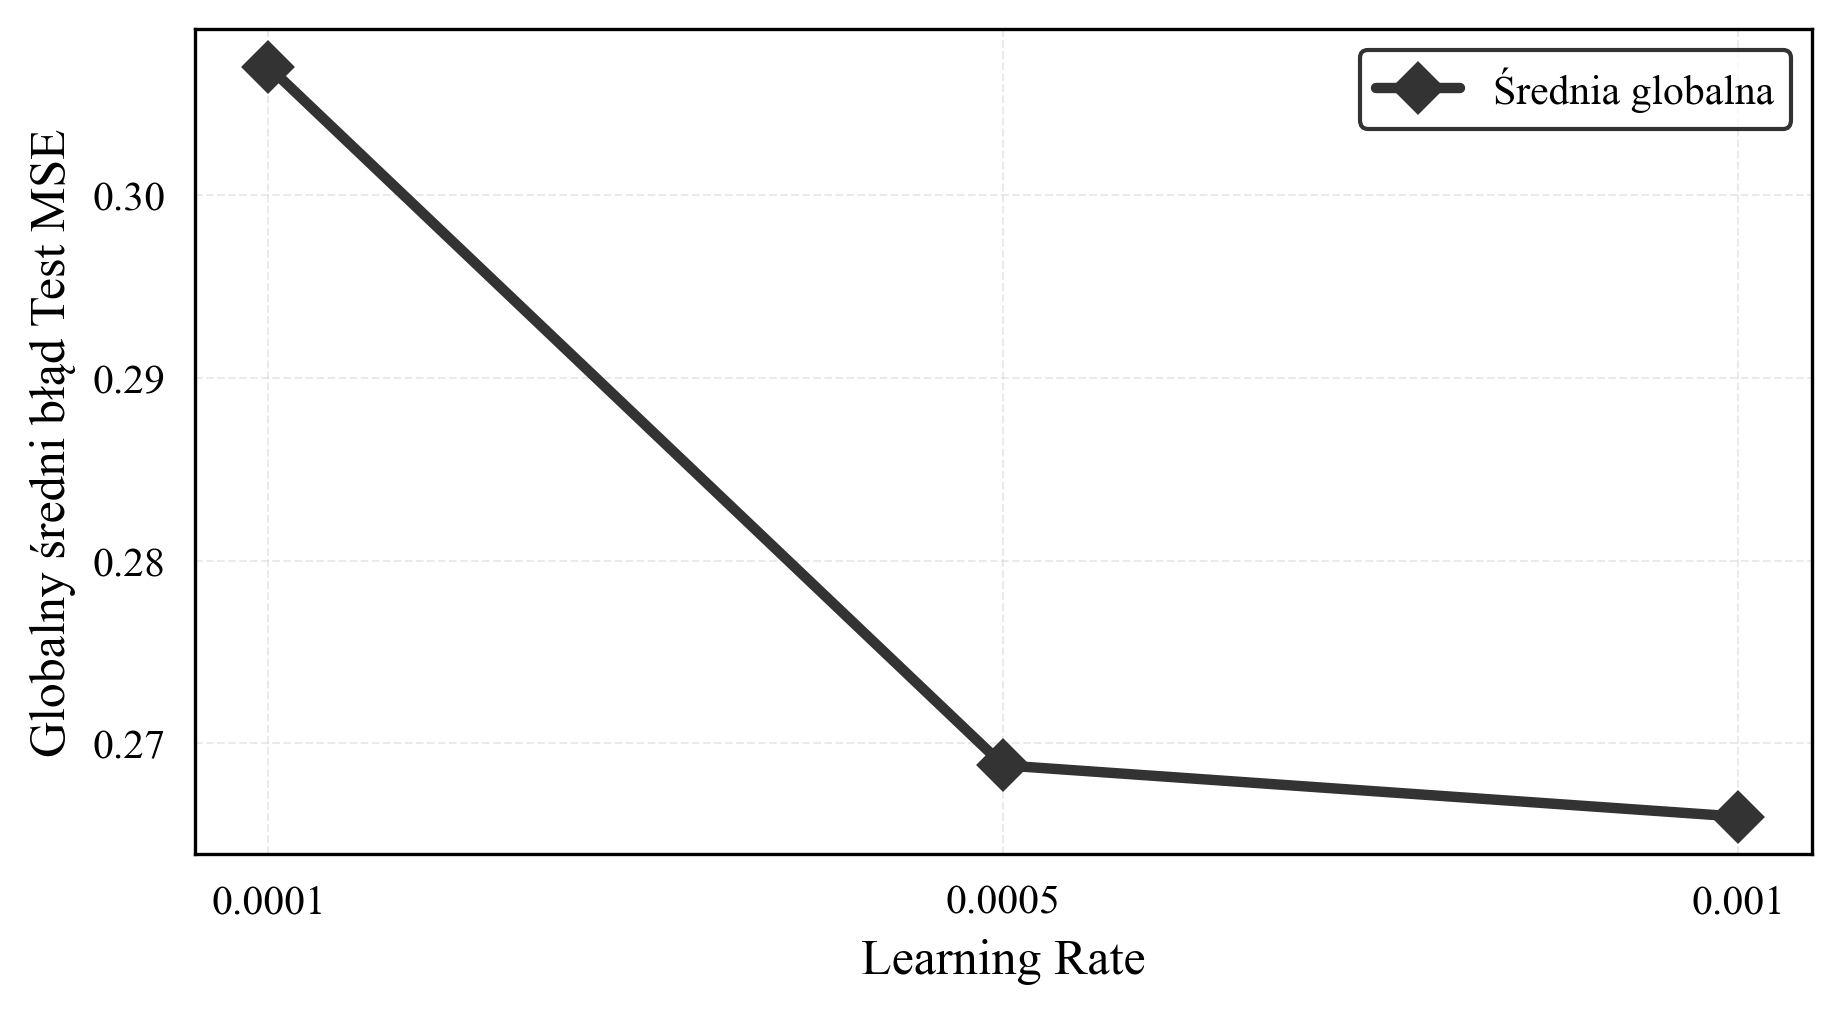

In [10]:
print("Generowanie makroskopowych zestawień statystycznych błędu MSE względem parametrów LR")
vis.generate_lr_summary_plots(checkpoints_dir='experiments/checkpoints1', plots_dir='../images/experiment1')


Granica Pareto: Zdolność generalizacyjna względem złożoności parametrycznej


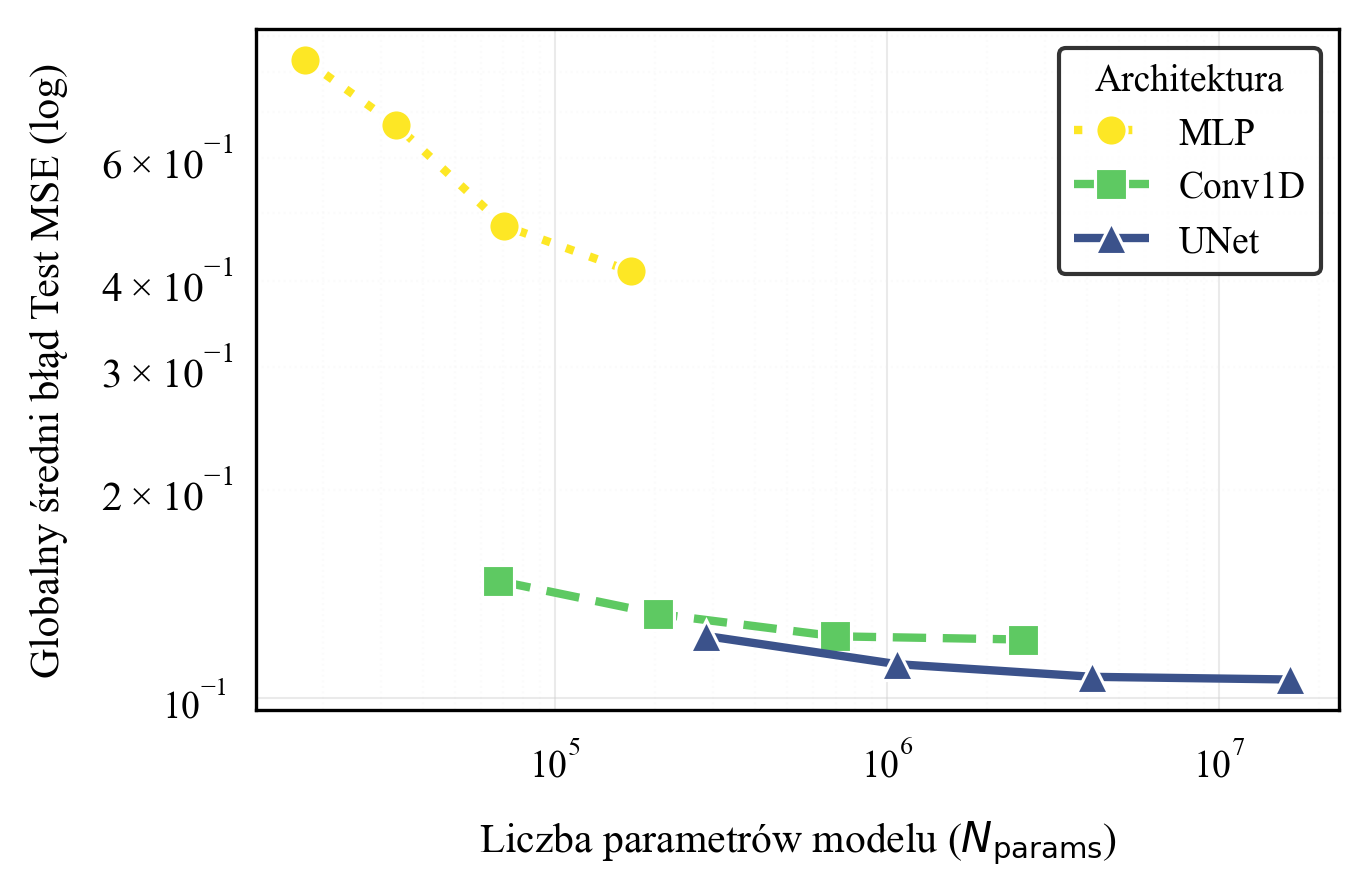

Pomyślnie zapisano globalny wykres złożoności: ../images/experiment1/stats/mse_vs_params_global.png


In [11]:
print("Granica Pareto: Zdolność generalizacyjna względem złożoności parametrycznej")
vis.plot_mse_vs_params_global(folder='experiments/checkpoints1')

Granica Pareto: Zdolność generalizacyjna względem złożoności parametrycznej


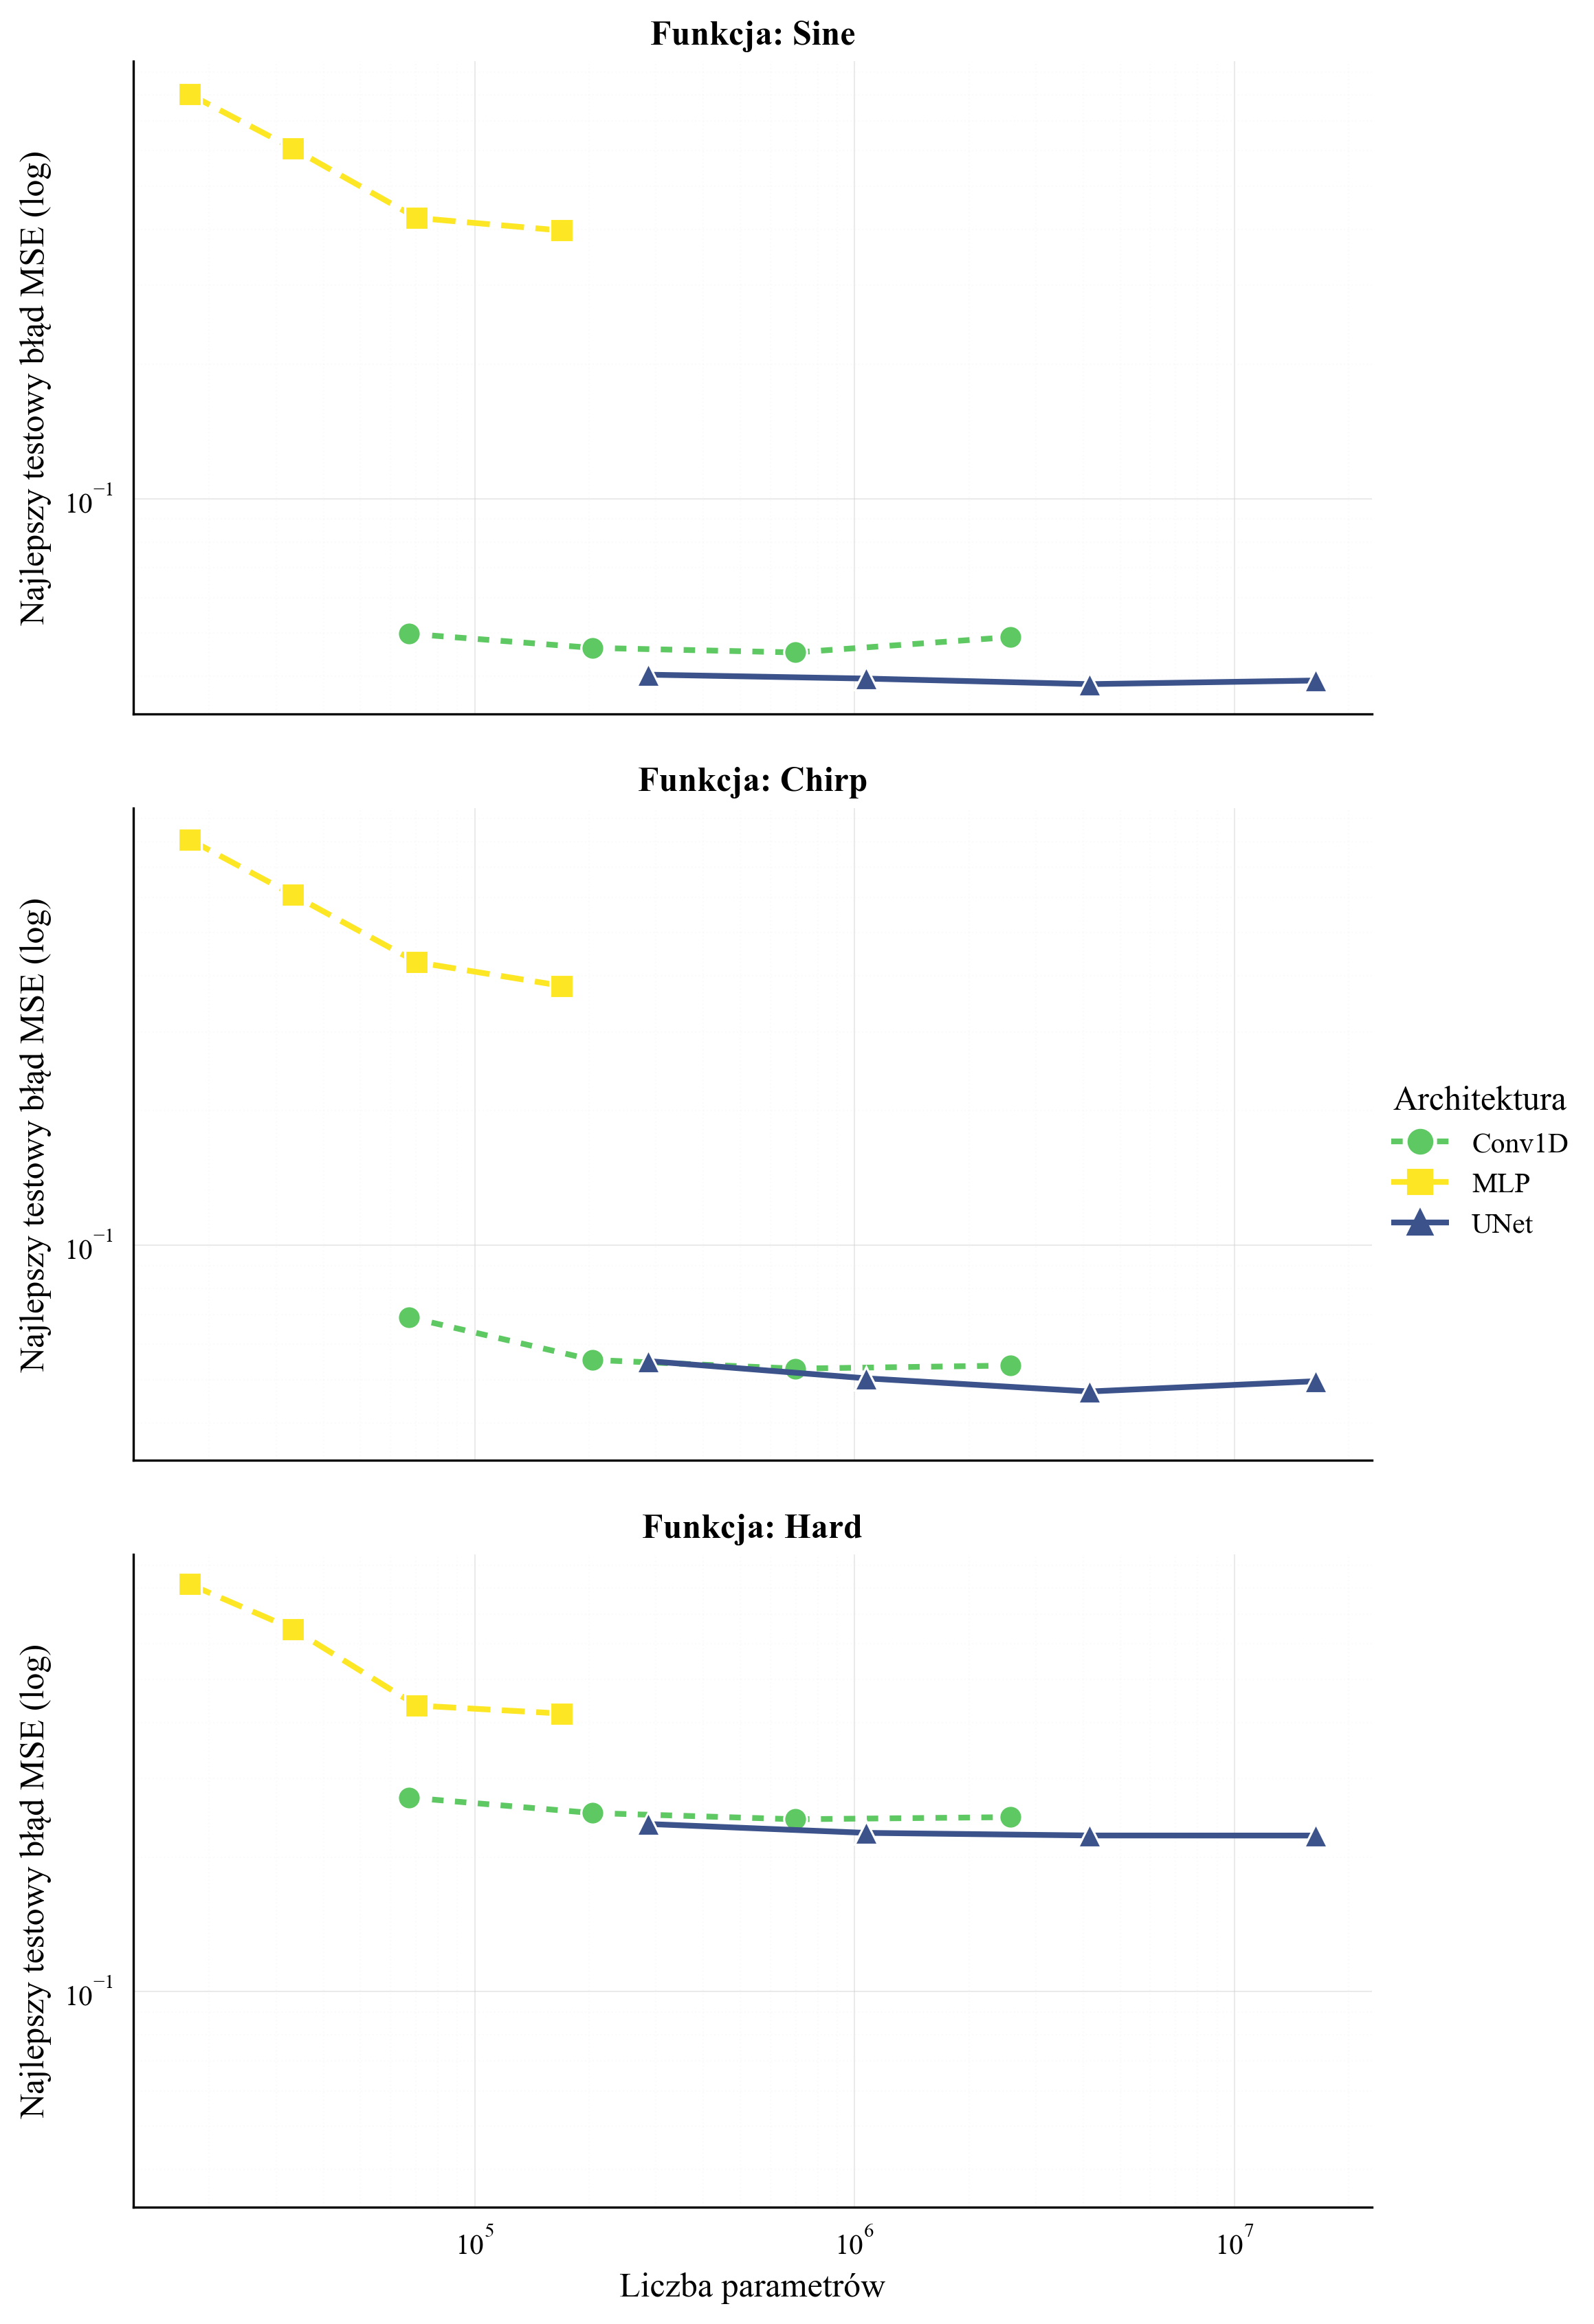

In [12]:
print("Granica Pareto: Zdolność generalizacyjna względem złożoności parametrycznej")
vis.plot_mse_vs_params_vertical(folder='experiments/checkpoints1')

Zbieżność procesu uczenia


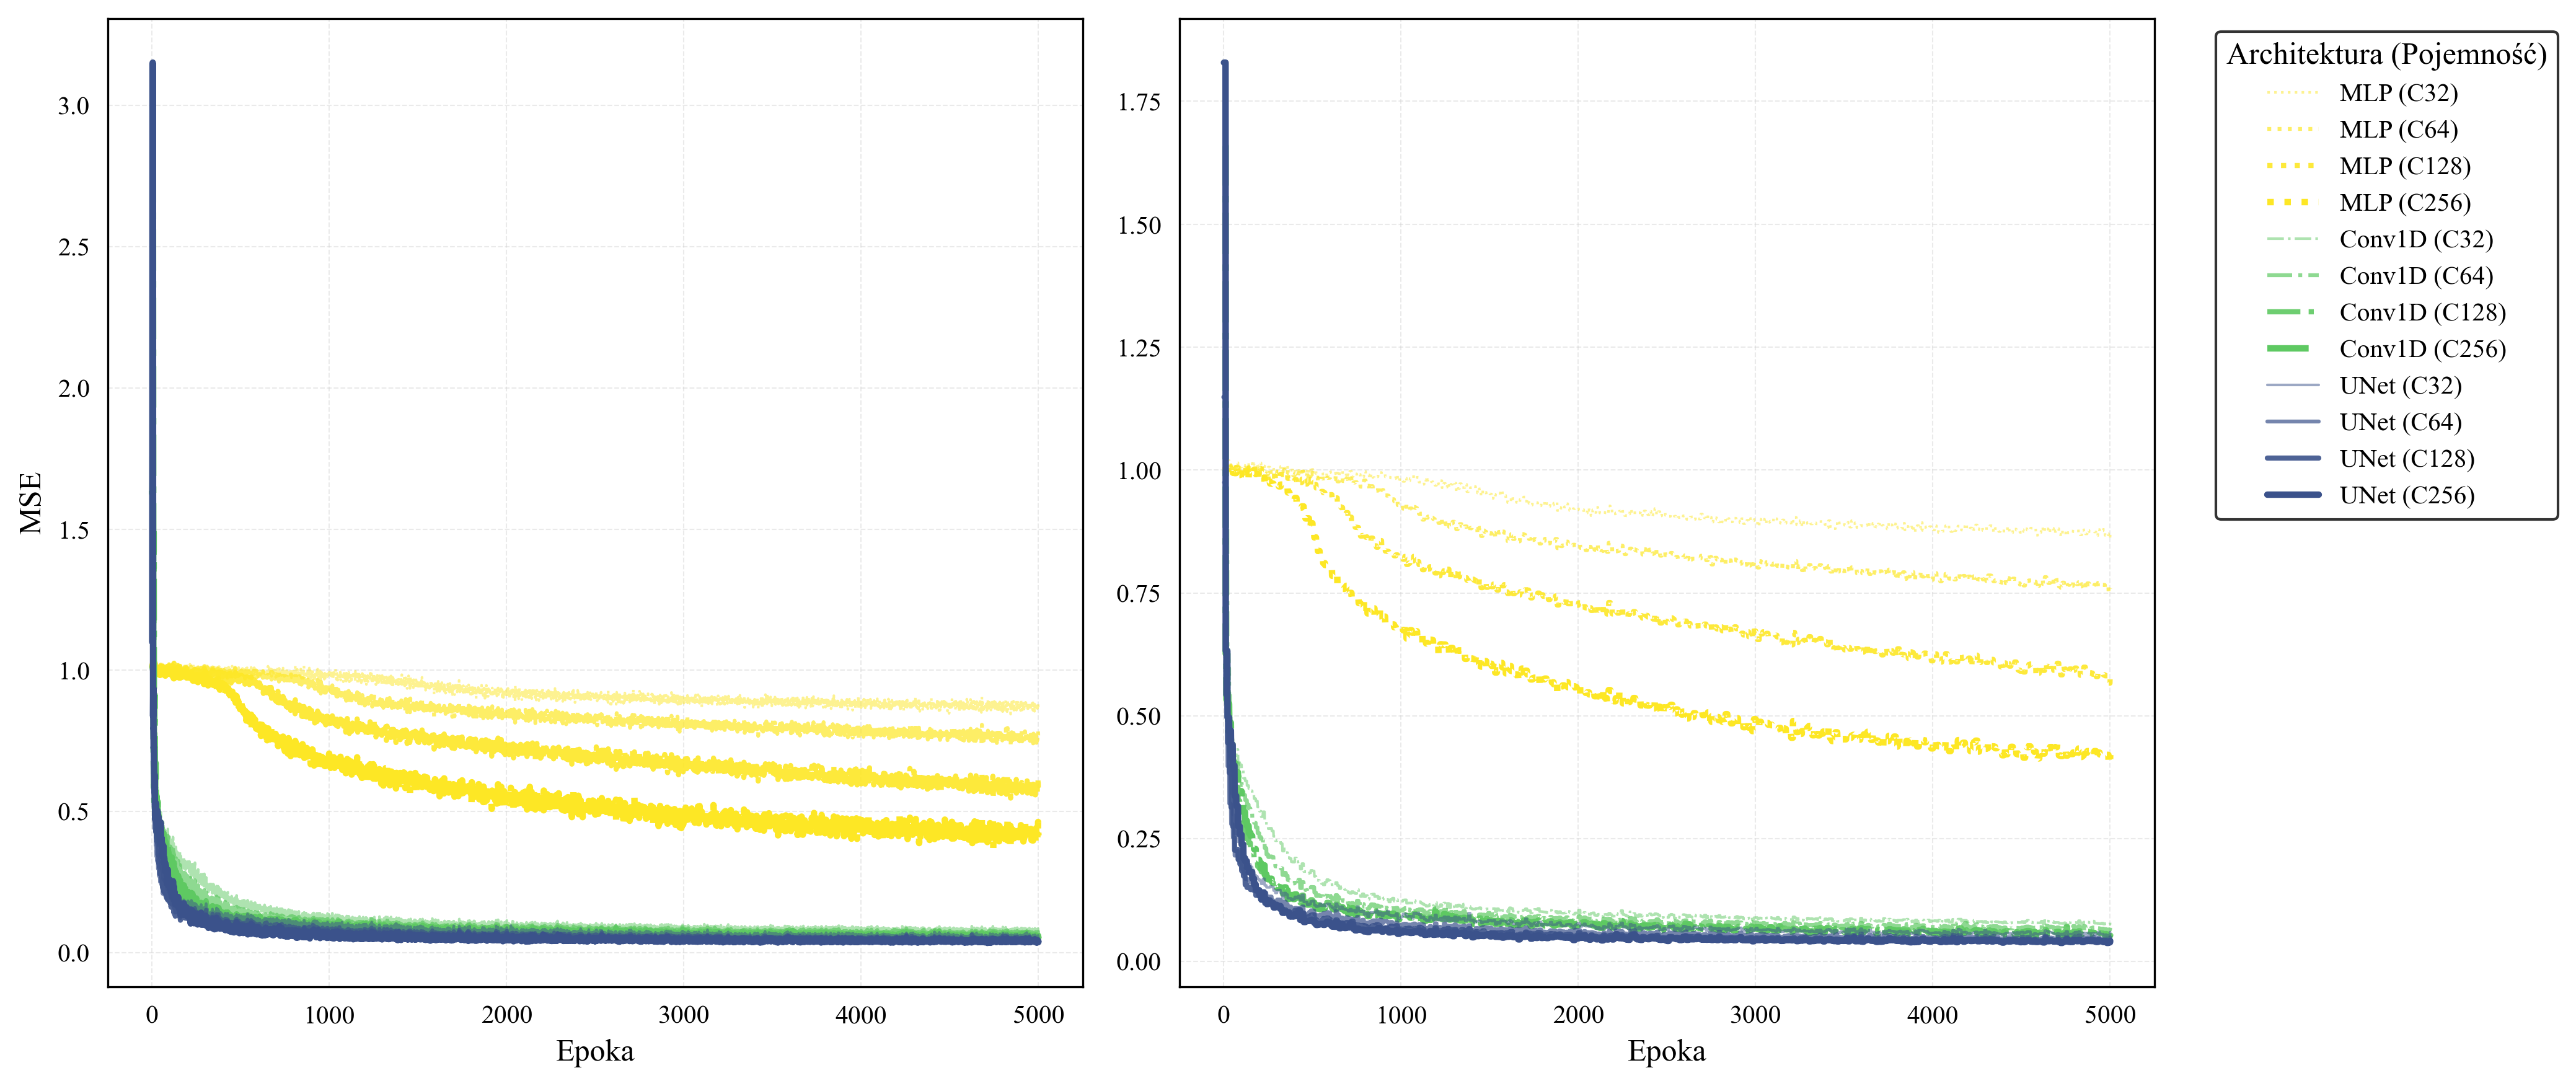

In [13]:
print("Zbieżność procesu uczenia")
vis.plot_learning_curves_unified(func_type='Sine', folder='experiments/checkpoints1')

In [14]:
print("Luka generalizacyjna")
df_overfit = vis.analyze_generalization_gap(df, top_n=10)
display(df_overfit.style.background_gradient(cmap='OrRd', subset=['Gap_Val_Train']).format("{:.5f}", subset=['Train_MSE', 'Val_MSE', 'Gap_Val_Train']))

Luka generalizacyjna


,Funkcja,Architektura,Pojemność,LR,Test_MSE,Train_MSE,Val_MSE,Gap_Val_Train
102,Hard,MLP,256,0.000100,0.419206,0.39213,0.42685,0.03472
104,Hard,MLP,256,0.000500,0.422991,0.39799,0.43111,0.03313
98,Hard,MLP,128,0.000500,0.437491,0.41227,0.44460,0.03234
100,Hard,MLP,128,0.001000,0.436710,0.41226,0.44429,0.03203
106,Hard,MLP,256,0.001000,0.419117,0.39635,0.42637,0.03002
30,Chirp,MLP,256,0.000100,0.412657,0.38628,0.41240,0.02611
174,Sine,MLP,256,0.000100,0.413409,0.39287,0.41866,0.02579
96,Hard,MLP,128,0.000100,0.566435,0.54579,0.57110,0.02531
28,Chirp,MLP,128,0.001000,0.429605,0.40582,0.43045,0.02463
34,Chirp,MLP,256,0.001000,0.380373,0.35831,0.38165,0.02334


In [15]:
summary_df = vis.generate_experiment_summary_from_files('experiments/checkpoints1')

if not summary_df.empty:
    print("10 konfiguracji z najniższym błędem testowym MSE:")
    display(summary_df.head(10).style.background_gradient(cmap='RdYlGn_r', subset=['MSE']))

    summary_df.to_csv("../images/experiment1/stats/experiment_1_summary.csv", index=False)
else:
    print("Nie udało się utworzyć tabeli. Sprawdź, czy w folderze są pliki _stats.pth.")

10 konfiguracji z najniższym błędem testowym MSE:


,Funkcja,Architektura,Pojemność,LR,T,MSE,Odchylenie Std,Liczba parametrów,Stabilność (CV %)
0,Sine,UNet,C128,0.000500,80,0.038454,0.001664,4153409,4.326421
1,Sine,UNet,C256,0.000100,80,0.039180,0.000907,16363585,2.314277
2,Sine,UNet,C256,0.000500,80,0.039282,0.001574,16363585,4.007223
3,Sine,UNet,C64,0.001000,80,0.039573,0.001673,1071169,4.227240
4,Sine,UNet,C256,0.001000,80,0.039602,0.000528,16363585,1.333804
5,Sine,UNet,C256,0.000100,100,0.040208,0.000102,16363585,0.253278
6,Sine,UNet,C256,0.000500,100,0.040247,0.000323,16363585,0.803572
7,Sine,UNet,C64,0.000500,100,0.040292,0.000643,1071169,1.595682
8,Sine,UNet,C128,0.000500,100,0.040378,0.000944,4153409,2.337447
9,Sine,UNet,C32,0.001000,80,0.040378,0.000972,285761,2.407380


In [16]:
pivot_df = df.pivot_table(
    index=['Architektura', 'Pojemność'], 
    columns=['LR', 'T'], 
    values='Test_MSE'
)

styled_table = pivot_df.style.background_gradient(cmap='viridis_r', axis=None) \
                             .format("{:.5f}") \
                             .highlight_min(axis=None, color='lightgreen')
display(styled_table)

In [17]:
if not df.empty:
    print("NAJLEPSZE KONFIGURACJE DLA KAŻDEJ FUNKCJI (Najniższe MSE):")
    best_per_signal = df.loc[df.groupby('Funkcja')['Test_MSE'].idxmin()]
    display(best_per_signal.sort_values('Test_MSE'))

    print("\nNAJGORSZE KONFIGURACJE DLA KAŻDEJ FUNKCJI (Najwyższe MSE):")
    worst_per_signal = df.loc[df.groupby('Funkcja')['Test_MSE'].idxmax()]
    display(worst_per_signal.sort_values('Test_MSE', ascending=False))

NAJLEPSZE KONFIGURACJE DLA KAŻDEJ FUNKCJI (Najniższe MSE):


,Funkcja,Architektura,Pojemność,LR,T,Train_MSE,Val_MSE,Test_MSE,Test_STD,Liczba parametrów
195,Sine,UNet,128,0.0005,80,0.038568,0.040634,0.038454,0.001664,4153409
51,Chirp,UNet,128,0.0005,80,0.047679,0.047280,0.047056,0.002819,4153409
128,Hard,UNet,256,0.0005,100,0.207120,0.223699,0.223530,0.008158,16363585



NAJGORSZE KONFIGURACJE DLA KAŻDEJ FUNKCJI (Najwyższe MSE):


,Funkcja,Architektura,Pojemność,LR,T,Train_MSE,Val_MSE,Test_MSE,Test_STD,Liczba parametrów
109,Hard,MLP,32,0.0001,80,0.868811,0.873487,0.877361,0.008212,17728
181,Sine,MLP,32,0.0001,80,0.864795,0.868613,0.871876,0.006736,17728
37,Chirp,MLP,32,0.0001,80,0.858907,0.863487,0.867971,0.007031,17728


In [18]:
if not df.empty:
    arch_analysis = df.pivot_table(
        index='Funkcja', 
        columns='Architektura', 
        values='Test_MSE', 
        aggfunc='mean' 
    )
    
    print("ŚREDNIE MSE ARCHITEKTURY W ZALEŻNOŚCI OD FUNKCJI:")
    display(arch_analysis.style.background_gradient(cmap='RdYlGn_r', axis=1))
    
    cap_analysis = df.pivot_table(
        index='Funkcja', 
        columns='Pojemność', 
        values='Test_MSE', 
        aggfunc='mean'
    )
    
    print("\nŚREDNIE MSE POJEMNOŚCI W ZALEŻNOŚCI OD FUNKCJI:")
    display(cap_analysis.style.background_gradient(cmap='RdYlGn_r', axis=1))

ŚREDNIE MSE ARCHITEKTURY W ZALEŻNOŚCI OD FUNKCJI:


Architektura,Conv1D,MLP,UNet
Funkcja,,,
Chirp,0.067079,0.590651,0.054993
Hard,0.271630,0.612722,0.239090
Sine,0.054798,0.591768,0.042716



ŚREDNIE MSE POJEMNOŚCI W ZALEŻNOŚCI OD FUNKCJI:


Pojemność,32,64,128,256
Funkcja,,,,
Chirp,0.325168,0.259554,0.194907,0.170667
Hard,0.464930,0.402434,0.326234,0.304324
Sine,0.311725,0.252717,0.189028,0.165573


In [19]:
import pandas as pd
import itertools
from IPython.display import display

if not df.empty:
    
    def find_best_combinations(data, params, degree=2, top_n=5):

        combinations = list(itertools.combinations(params, degree))
        
        results = []
        for combo in combinations:
            combo_list = list(combo)
            
            grouped = data.groupby(combo_list)['Test_MSE'].mean().reset_index()
            best_in_combo = grouped.sort_values('Test_MSE').iloc[0]
            zbadane_parametry = " + ".join(combo_list)
            zwyciezkie_wartosci = " + ".join([str(best_in_combo[c]) for c in combo_list])
            
            results.append({
                'Zbadane połączenie (Wymiary)': zbadane_parametry,
                'Zwycięska konfiguracja': zwyciezkie_wartosci,
                'Średnie MSE': best_in_combo['Test_MSE']
            })
            
        res_df = pd.DataFrame(results).sort_values('Średnie MSE')
        return res_df.head(top_n)

    hiperparametry = ['Architektura', 'Pojemność', 'LR', 'T']

    print("TOP 10 NAJLEPSZYCH PAR:")
    top_pary = find_best_combinations(df, hiperparametry, degree=2, top_n=5)
    display(top_pary.style.background_gradient(cmap='RdYlGn_r', subset=['Średnie MSE']))

    print("\nTOP 10 NAJLEPSZYCH TRÓJEK:")
    top_trojki = find_best_combinations(df, hiperparametry, degree=3, top_n=5)
    display(top_trojki.style.background_gradient(cmap='RdYlGn_r', subset=['Średnie MSE']))

    print("\n TOP 10 NAJLEPSZYCH KONFIGURACJI:")

    top_czworki = df.groupby(['Architektura', 'Pojemność', 'LR', 'T'])['Test_MSE'].mean().reset_index()
    top_czworki = top_czworki.sort_values('Test_MSE').head(10)
    
    display(top_czworki.style.background_gradient(cmap='RdYlGn_r', subset=['Test_MSE']))

TOP 10 NAJLEPSZYCH PAR:


,Zbadane połączenie (Wymiary),Zwycięska konfiguracja,Średnie MSE
0,Architektura + Pojemność,UNet + 256,0.106507
1,Architektura + LR,UNet + 0.001,0.108436
2,Architektura + T,UNet + 100,0.111562
3,Pojemność + LR,256.0 + 0.001,0.210492
4,Pojemność + T,256.0 + 100.0,0.211579



TOP 10 NAJLEPSZYCH TRÓJEK:


,Zbadane połączenie (Wymiary),Zwycięska konfiguracja,Średnie MSE
0,Architektura + Pojemność + LR,UNet + 128 + 0.0005,0.104732
1,Architektura + Pojemność + T,UNet + 256 + 100,0.106060
2,Architektura + LR + T,UNet + 0.0005 + 100,0.107736
3,Pojemność + LR + T,256.0 + 0.001 + 100.0,0.208556



 TOP 10 NAJLEPSZYCH KONFIGURACJI:


,Architektura,Pojemność,LR,T,Test_MSE
62,UNet,128,0.000500,80,0.104696
63,UNet,128,0.000500,100,0.104768
69,UNet,256,0.000500,100,0.104912
68,UNet,256,0.000500,80,0.105561
67,UNet,256,0.000100,100,0.105611
65,UNet,128,0.001000,100,0.105769
59,UNet,64,0.001000,100,0.106511
57,UNet,64,0.000500,100,0.106860
64,UNet,128,0.001000,80,0.107042
66,UNet,256,0.000100,80,0.107045


In [20]:
print("Przykładowy wybór do Eksperymentu II")
candidates = vis.get_scientific_sdedit_candidates(df)
display(candidates.style.background_gradient(cmap='viridis_r', subset=['Test_MSE']))

Przykładowy wybór do Eksperymentu II


,Funkcja,Architektura,Pojemność,LR,T,Test_MSE,Powód wyboru
0,Chirp,UNet,128,0.000500,80,0.047056,Najniższy błąd dla tego sygnału
1,Chirp,UNet,128,0.001000,80,0.049409,Najniższy błąd dla tego sygnału
2,Chirp,UNet,256,0.000100,80,0.049618,Najniższy błąd dla tego sygnału
3,Chirp,Conv1D,128,0.001000,80,0.052940,Najlepszy w klasie Conv1D
4,Chirp,MLP,256,0.001000,100,0.380373,Najlepszy w klasie MLP
5,Hard,UNet,256,0.000500,100,0.223530,Najniższy błąd dla tego sygnału
6,Hard,UNet,128,0.000500,100,0.223596,Najniższy błąd dla tego sygnału
7,Hard,UNet,128,0.001000,100,0.225303,Najniższy błąd dla tego sygnału
8,Hard,Conv1D,128,0.001000,100,0.243089,Najlepszy w klasie Conv1D
9,Hard,MLP,256,0.001000,100,0.419117,Najlepszy w klasie MLP


In [21]:
if not df.empty:

    print("WSPÓŁCZYNNIK CV - NAJBARDZIEJ NIESTABILNE MODELE")
    unstable, stable = vis.analyze_stability_cv(df, top_n=10)
    display(unstable.style.background_gradient(cmap='Reds', subset=['CV_%']).format("{:.5f}", subset=['Test_MSE', 'Test_STD']).format("{:.2f}%", subset=['CV_%']))

    print("WSPÓŁCZYNNIK CV - NAJBARDZIEJ STABILNE MODELE")
    display(stable.style.background_gradient(cmap='Greens_r', subset=['CV_%']).format("{:.5f}", subset=['Test_MSE', 'Test_STD']).format("{:.2f}%", subset=['CV_%']))

    print("NAJGORSZE KONFIGURACJE")
    df_worst = vis.analyze_worst_combinations(df, top_n=10)
    display(df_worst.style.background_gradient(cmap='Reds', subset=['Test_MSE']).format("{:.5f}", subset=['Test_MSE']))


else:
    print("[BŁĄD] Nie udało się wczytać danych z folderu 'checkpoints1'.")

WSPÓŁCZYNNIK CV - NAJBARDZIEJ NIESTABILNE MODELE


,Funkcja,Architektura,Pojemność,LR,Test_MSE,Test_STD,CV_%
52,Chirp,UNet,128,0.001000,0.05065,0.00639,12.61%
148,Sine,Conv1D,128,0.001000,0.04924,0.00518,10.53%
17,Chirp,Conv1D,32,0.001000,0.06904,0.00673,9.75%
58,Chirp,UNet,256,0.001000,0.05282,0.00505,9.57%
70,Chirp,UNet,64,0.001000,0.05224,0.00489,9.37%
57,Chirp,UNet,256,0.000500,0.04987,0.00459,9.21%
48,Chirp,UNet,128,0.000100,0.05404,0.00489,9.06%
56,Chirp,UNet,256,0.000500,0.05096,0.00454,8.91%
197,Sine,UNet,128,0.001000,0.04112,0.00366,8.91%
54,Chirp,UNet,256,0.000100,0.05056,0.00450,8.91%


WSPÓŁCZYNNIK CV - NAJBARDZIEJ STABILNE MODELE


,Funkcja,Architektura,Pojemność,LR,Test_MSE,Test_STD,CV_%
198,Sine,UNet,256,0.000100,0.04021,0.00010,0.25%
38,Chirp,MLP,32,0.000500,0.81004,0.00349,0.43%
40,Chirp,MLP,32,0.001000,0.80849,0.00362,0.45%
36,Chirp,MLP,32,0.000100,0.86265,0.00425,0.49%
108,Hard,MLP,32,0.000100,0.87003,0.00451,0.52%
110,Hard,MLP,32,0.000500,0.82550,0.00455,0.55%
180,Sine,MLP,32,0.000100,0.86554,0.00502,0.58%
39,Chirp,MLP,32,0.000500,0.81098,0.00471,0.58%
41,Chirp,MLP,32,0.001000,0.80906,0.00475,0.59%
184,Sine,MLP,32,0.001000,0.80353,0.00551,0.69%


NAJGORSZE KONFIGURACJE


,Funkcja,Architektura,Pojemność,LR,T,Test_MSE
109,Hard,MLP,32,0.000100,80,0.87736
181,Sine,MLP,32,0.000100,80,0.87188
108,Hard,MLP,32,0.000100,100,0.87003
37,Chirp,MLP,32,0.000100,80,0.86797
180,Sine,MLP,32,0.000100,100,0.86554
36,Chirp,MLP,32,0.000100,100,0.86265
111,Hard,MLP,32,0.000500,80,0.82832
110,Hard,MLP,32,0.000500,100,0.82550
113,Hard,MLP,32,0.001000,80,0.81830
112,Hard,MLP,32,0.001000,100,0.81633
